# Prepare forcings without specific frequencies of variability
- do "decomposition.ipynb" first

## imports

In [1]:
import sys
import os

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import h5py as h5

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

# regridding package
import xesmf as xe

# statistics package
#import skill_metrics as sm


# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("h5py version =", h5.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("xesmf version =", xe.__version__)


wrkdir = "/g/data/es60/SEAPODYM"
os.chdir(wrkdir)


python version = 3.10.
numpy version = 2.2.5
pandas version = 2.3.3
xarray version = 2025.4.0
scipy version = 1.15.3
h5py version = 3.15.1
matplotlib version = 3.10.6
cmocean version = v3.0.3
cartopy version = 0.24.1
xesmf version = 0.8.10


### Set up dask client

In [2]:
from dask.distributed import Client, LocalCluster

# Rule of thumb here:
# - 56 workers × 1 thread each (good isolation for NumPy/xarray)
# - ~8 GB per worker → 56 * 8 = 448 GB (leaves headroom for OS, Jupyter, scheduler)
cluster = LocalCluster(
    n_workers=28,
    threads_per_worker=1,
    memory_limit="8GB",
    # Optional niceties:
    dashboard_address=":8787",   # or ":0" for random free port
    processes=True,
)

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 208.62 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:39811,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43747,Total threads: 1
Dashboard: /proxy/44821/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:38457,


## Load the forcings datasets

In [2]:
%%time

sst = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_sst_1958_2022.nc")['sst']
mld = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_mld_1958_2022.nc")['mld']
zeu = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_zeu_1958_2022.nc")['zeu']
pp = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_pp_1958_2022.nc")['pp']
pp75 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_pp75_1958_2022.nc")['pp75']
uo = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_uo_1958_2022.nc")['uo']
vo = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_vo_1958_2022.nc")['vo']
T_L1 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_T_L1_1958_2022.nc")['T_L1']
T_L2 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_T_L2_1958_2022.nc")['T_L2']
T_L3 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_T_L3_1958_2022.nc")['T_L3']
O2_L1 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_O2_L1_1958_2022.nc")['O2_L1'] * 44.661
O2_L2 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_O2_L2_1958_2022.nc")['O2_L2'] * 44.661
O2_L3 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_O2_L3_1958_2022.nc")['O2_L3'] * 44.661
U_L1 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_U_L1_1958_2022.nc")['U_L1']
U_L2 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_U_L2_1958_2022.nc")['U_L2']
U_L3 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_U_L3_1958_2022.nc")['U_L3']
V_L1 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_V_L1_1958_2022.nc")['V_L1']
V_L2 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_V_L2_1958_2022.nc")['V_L2']
V_L3 = xr.open_dataset("/g/data/es60/SEAPODYM/forcings_netCDF/ipo_jra55np_1x30d_V_L3_1958_2022.nc")['V_L3']

lons = sst.coords['lon']
lats = sst.coords['lat']


CPU times: user 704 ms, sys: 3.37 s, total: 4.08 s
Wall time: 45.7 s


## Load the Intrinsic Mode Functions for each forcing (prepared earlier by "decomposition.ipynb")

In [3]:
%%time

sst_imfs   = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_sst_CEEMDAN.nc")['sst_imfs']
mld_imfs   = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_mld_CEEMDAN.nc")['mld_imfs']
zeu_imfs   = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_zeu_CEEMDAN.nc")['zeu_imfs']
pp_imfs    = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_pp_CEEMDAN.nc")['pp_imfs']
pp75_imfs  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_pp75_CEEMDAN.nc")['pp75_imfs']
uo_imfs    = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_uo_CEEMDAN.nc")['uo_imfs']
vo_imfs    = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_vo_CEEMDAN.nc")['vo_imfs']
T_L1_imfs  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_T_L1_CEEMDAN.nc")['T_L1_imfs']
T_L2_imfs  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_T_L2_CEEMDAN.nc")['T_L2_imfs']
T_L3_imfs  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_T_L3_CEEMDAN.nc")['T_L3_imfs']
O2_L1_imfs = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_O2_L1_CEEMDAN.nc")['O2_L1_imfs']
O2_L2_imfs = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_O2_L2_CEEMDAN.nc")['O2_L2_imfs']
O2_L3_imfs = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_O2_L3_CEEMDAN.nc")['O2_L3_imfs']
U_L1_imfs  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_U_L1_CEEMDAN.nc")['U_L1_imfs']
U_L2_imfs  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_U_L2_CEEMDAN.nc")['U_L2_imfs']
U_L3_imfs  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_U_L3_CEEMDAN.nc")['U_L3_imfs']
V_L1_imfs  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_V_L1_CEEMDAN.nc")['V_L1_imfs']
V_L2_imfs  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_V_L2_CEEMDAN.nc")['V_L2_imfs']
V_L3_imfs  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_V_L3_CEEMDAN.nc")['V_L3_imfs']

sst_trend   = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_sst_CEEMDAN.nc")['sst_trend']
mld_trend   = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_mld_CEEMDAN.nc")['mld_trend']
zeu_trend   = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_zeu_CEEMDAN.nc")['zeu_trend']
pp_trend    = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_pp_CEEMDAN.nc")['pp_trend']
pp75_trend  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_pp75_CEEMDAN.nc")['pp75_trend']
uo_trend    = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_uo_CEEMDAN.nc")['uo_trend']
vo_trend    = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_vo_CEEMDAN.nc")['vo_trend']
T_L1_trend  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_T_L1_CEEMDAN.nc")['T_L1_trend']
T_L2_trend  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_T_L2_CEEMDAN.nc")['T_L2_trend']
T_L3_trend  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_T_L3_CEEMDAN.nc")['T_L3_trend']
O2_L1_trend = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_O2_L1_CEEMDAN.nc")['O2_L1_trend']
O2_L2_trend = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_O2_L2_CEEMDAN.nc")['O2_L2_trend']
O2_L3_trend = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_O2_L3_CEEMDAN.nc")['O2_L3_trend']
U_L1_trend  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_U_L1_CEEMDAN.nc")['U_L1_trend']
U_L2_trend  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_U_L2_CEEMDAN.nc")['U_L2_trend']
U_L3_trend  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_U_L3_CEEMDAN.nc")['U_L3_trend']
V_L1_trend  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_V_L1_CEEMDAN.nc")['V_L1_trend']
V_L2_trend  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_V_L2_CEEMDAN.nc")['V_L2_trend']
V_L3_trend  = xr.open_dataset("/g/data/es60/SEAPODYM/pearse_GAMs/EMD_forcings/SEAPODYM_imfs_V_L3_CEEMDAN.nc")['V_L3_trend']




CPU times: user 639 ms, sys: 845 ms, total: 1.48 s
Wall time: 5.35 s


## Make an example figure to showcase SST trends with and without the bands of variability

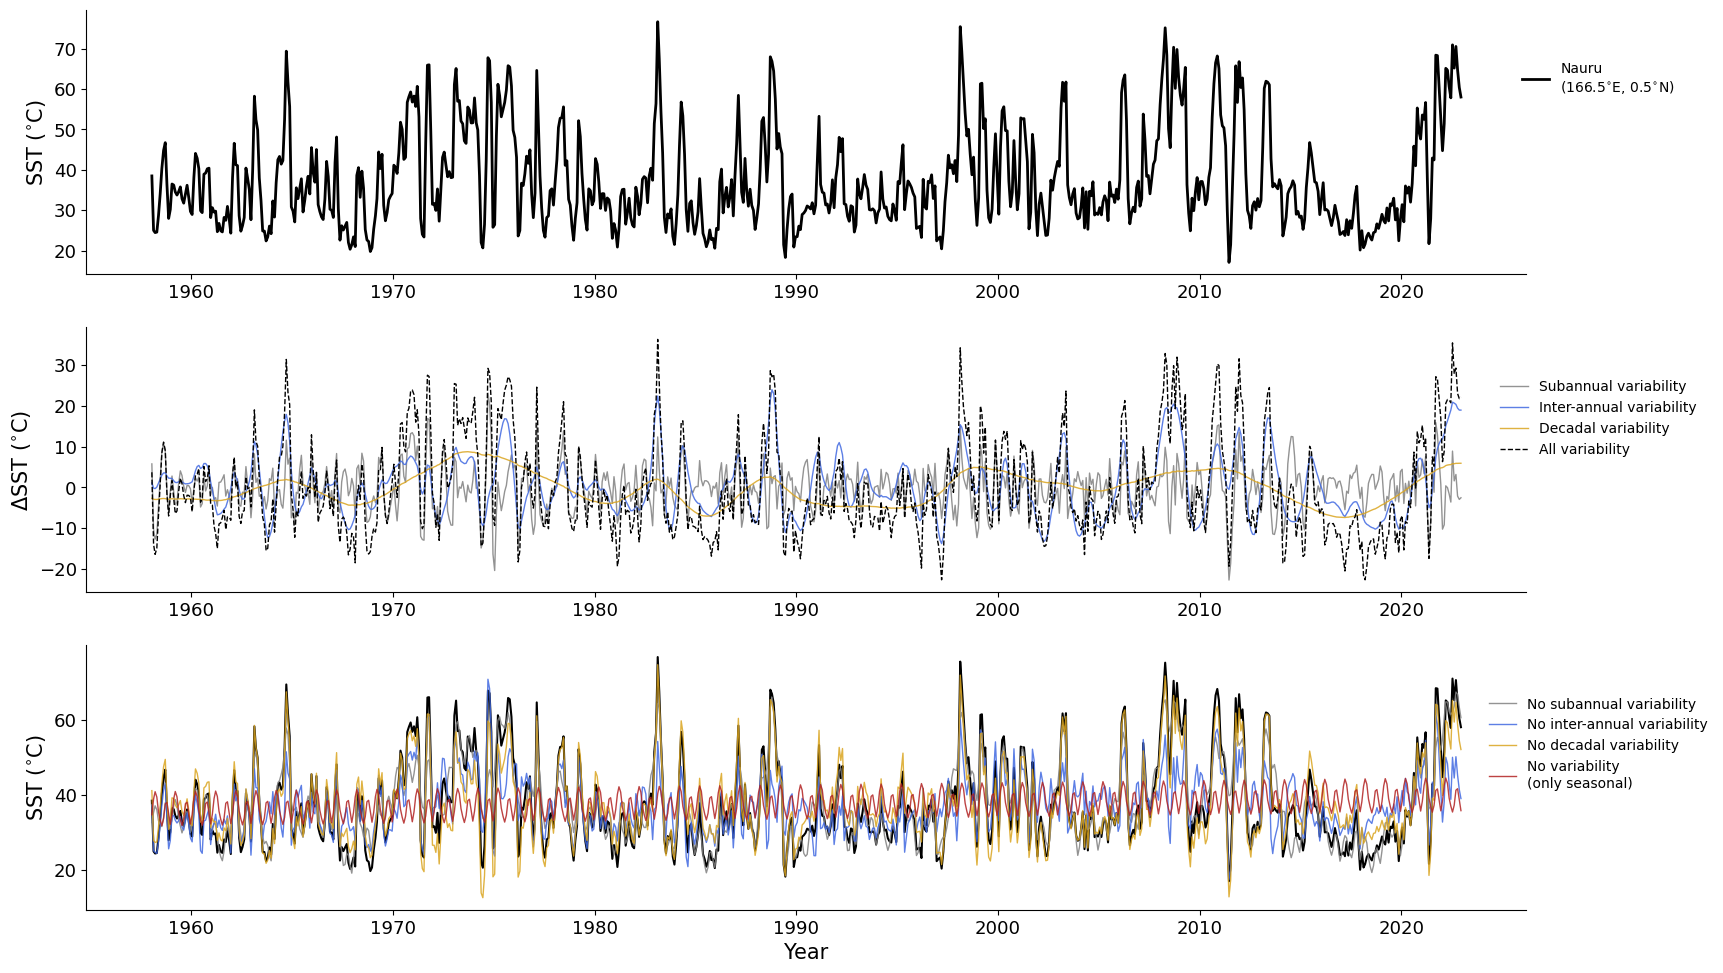

In [4]:

tmp = pp.sel(lon=166.5,lat=0.5, method='nearest')
imf = pp_imfs.sel(lon=166.5,lat=0.5, method='nearest')
time = pp.coords['time']

fslab = 15
fstic = 13

cols = ['k', 'grey', 'royalblue', 'goldenrod', 'firebrick']
lwid = [2, 1, 1, 1, 1]
alf = [1, 0.85, 0.85, 0.85, 0.85]

fig = plt.figure(figsize=(18,10))
gs = GridSpec(3, 1)

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])
ax3 = plt.subplot(gs[2])
ax1.spines[['top','right']].set_visible(False)
ax2.spines[['top','right']].set_visible(False)
ax3.spines[['top','right']].set_visible(False)
ax1.tick_params(labelsize=fstic)
ax2.tick_params(labelsize=fstic)
ax3.tick_params(labelsize=fstic)

ax1.plot(time, tmp, color=cols[0], linewidth=lwid[0], alpha=alf[0], label="Nauru\n(166.5$^{\circ}$E, 0.5$^{\circ}$N)")
ax1.legend(frameon=False, ncol=1, bbox_to_anchor=(1.05,0.85), loc='upper center')

ax2.plot(time, imf.isel(IMF=0), color=cols[1], linewidth=lwid[1], alpha=alf[1], label='Subannual variability')
ax2.plot(time, imf.isel(IMF=1), color=cols[2], linewidth=lwid[2], alpha=alf[2], label='Inter-annual variability')
ax2.plot(time, imf.isel(IMF=2), color=cols[3], linewidth=lwid[3], alpha=alf[3], label='Decadal variability')
#ax2.plot(time, imf.isel(IMF=3), color=cols[4], linewidth=lwid[4], alpha=alf[4], label='Multi-decadal variability')
ax2.plot(time, imf.sum(dim="IMF"), color=cols[0], linewidth=lwid[4], alpha=alf[0], linestyle='--', label='All variability')
ax2.legend(frameon=False, ncol=1, bbox_to_anchor=(1.05,0.85), loc='upper center')

ax3.plot(time, tmp, color=cols[0])
ax3.plot(time, tmp - imf.isel(IMF=0), color=cols[1], linewidth=lwid[1], alpha=alf[1], label='No subannual variability')
ax3.plot(time, tmp - imf.isel(IMF=1), color=cols[2], linewidth=lwid[2], alpha=alf[2], label='No inter-annual variability')
ax3.plot(time, tmp - imf.isel(IMF=2), color=cols[3], linewidth=lwid[3], alpha=alf[3], label='No decadal variability')
#ax3.plot(time, tmp - imf.isel(IMF=3), color=cols[4], linewidth=lwid[4], alpha=alf[4], label='No multi-decadal variability')
ax3.plot(time, tmp - imf.sum(dim="IMF"), color=cols[4], linewidth=lwid[4], alpha=alf[4], label='No variability\n(only seasonal)')
ax3.legend(frameon=False, ncol=1, bbox_to_anchor=(1.05,0.85), loc='upper center')

ax1.set_ylabel("SST ($^{\circ}$C)", fontsize=fslab)
ax2.set_ylabel("$\Delta$SST ($^{\circ}$C)", fontsize=fslab)
ax3.set_ylabel("SST ($^{\circ}$C)", fontsize=fslab)
ax3.set_xlabel("Year", fontsize=fslab)

plt.subplots_adjust(left=0.05, right=0.85, top=0.95, bottom=0.05)


In [40]:
fig.savefig("./pearse_GAMs/figures/Nauru_SST_IMF_decomposition.png", dpi=300)
fig.savefig("./pearse_GAMs/figures/Nauru_SST_IMF_decomposition_transparent.png", dpi=300, transparent=True)

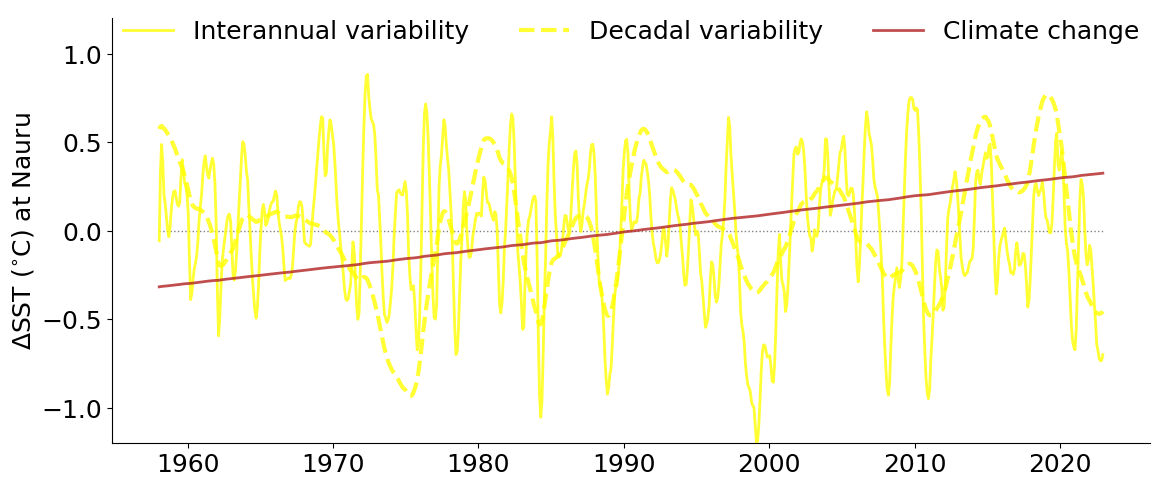

In [5]:

tmp = sst.sel(lon=166.5,lat=0.5, method='nearest')
imf = sst_imfs.sel(lon=166.5,lat=0.5, method='nearest')
time = sst.coords['time']
trend = sst_trend.sel(lon=166.5,lat=0.5, method='nearest').values/10.0/12.0 * np.arange(-len(time)/2, len(time)/2)


fslab = 18
fstic = 15

cols = ['k','yellow', 'yellow', 'firebrick']
lwid = [1, 2, 3, 2]
alf = [0.5, 0.8, 0.8, 0.8]

fig = plt.figure(figsize=(12,5))
gs = GridSpec(1, 1)

ax1 = plt.subplot(gs[0])
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(labelsize=fslab)

#ax1.plot(time, imf.isel(IMF=0), color=cols[0], linewidth=lwid[0], alpha=alf[0], label='Subannual variability')
ax1.plot(time, trend*0, color=cols[0], linewidth=lwid[0], alpha=alf[0], linestyle=':')
ax1.plot(time, imf.isel(IMF=1), color=cols[1], linewidth=lwid[1], alpha=alf[1], label='Interannual variability')
ax1.plot(time, imf.isel(IMF=2), color=cols[2], linewidth=lwid[2], alpha=alf[2], linestyle='--', label='Decadal variability')
ax1.plot(time, trend + imf.isel(IMF=3), color=cols[3], linewidth=lwid[3], alpha=alf[3], label='Climate change')
ax1.legend(frameon=False, ncol=3, bbox_to_anchor=(.5,1.05), loc='upper center', fontsize=fslab)
ax1.set_ylim(-1.2, 1.2)
ax1.set_ylabel("$\Delta$SST ($^{\circ}$C) at Nauru", fontsize=fslab)
#ax1.set_xlabel("Year", fontsize=fslab)

plt.subplots_adjust(left=0.085, right=0.95, top=0.95, bottom=0.1)

fig.savefig("./pearse_GAMs/figures/Nauru_deltaSST_transparent.png", dpi=300, transparent=True)


In [6]:
os.getcwd()

'/g/data/es60/SEAPODYM'

## Determine if the IMFs are positively or negatively correlated with the raw signal

In [7]:
%%time

levs = np.arange(-1,1.01,0.1)
colmap = lighten(cmo.balance, 0.8)

r_sst_HF = xr.corr(sst, sst_imfs.isel(IMF=0), dim='time')
r_sst_MF = xr.corr(sst, sst_imfs.isel(IMF=1), dim='time')
r_sst_LF = xr.corr(sst, sst_imfs.isel(IMF=2), dim='time')
r_sst_VLF = xr.corr(sst, sst_imfs.isel(IMF=3), dim='time')

r_mld_HF = xr.corr(mld, mld_imfs.isel(IMF=0), dim='time')
r_mld_MF = xr.corr(mld, mld_imfs.isel(IMF=1), dim='time')
r_mld_LF = xr.corr(mld, mld_imfs.isel(IMF=2), dim='time')
r_mld_VLF = xr.corr(mld, mld_imfs.isel(IMF=3), dim='time')

r_zeu_HF = xr.corr(zeu, zeu_imfs.isel(IMF=0), dim='time')
r_zeu_MF = xr.corr(zeu, zeu_imfs.isel(IMF=1), dim='time')
r_zeu_LF = xr.corr(zeu, zeu_imfs.isel(IMF=2), dim='time')
r_zeu_VLF = xr.corr(zeu, zeu_imfs.isel(IMF=3), dim='time')

r_pp_HF = xr.corr(pp, pp_imfs.isel(IMF=0), dim='time')
r_pp_MF = xr.corr(pp, pp_imfs.isel(IMF=1), dim='time')
r_pp_LF = xr.corr(pp, pp_imfs.isel(IMF=2), dim='time')
r_pp_VLF = xr.corr(pp, pp_imfs.isel(IMF=3), dim='time')

r_pp75_HF = xr.corr(pp75, pp75_imfs.isel(IMF=0), dim='time')
r_pp75_MF = xr.corr(pp75, pp75_imfs.isel(IMF=1), dim='time')
r_pp75_LF = xr.corr(pp75, pp75_imfs.isel(IMF=2), dim='time')
r_pp75_VLF = xr.corr(pp75, pp75_imfs.isel(IMF=3), dim='time')

r_uo_HF = xr.corr(uo, uo_imfs.isel(IMF=0), dim='time')
r_uo_MF = xr.corr(uo, uo_imfs.isel(IMF=1), dim='time')
r_uo_LF = xr.corr(uo, uo_imfs.isel(IMF=2), dim='time')
r_uo_VLF = xr.corr(uo, uo_imfs.isel(IMF=3), dim='time')

r_vo_HF = xr.corr(vo, vo_imfs.isel(IMF=0), dim='time')
r_vo_MF = xr.corr(vo, vo_imfs.isel(IMF=1), dim='time')
r_vo_LF = xr.corr(vo, vo_imfs.isel(IMF=2), dim='time')
r_vo_VLF = xr.corr(vo, vo_imfs.isel(IMF=3), dim='time')

r_T_L1_HF = xr.corr(T_L1, T_L1_imfs.isel(IMF=0), dim='time')
r_T_L1_MF = xr.corr(T_L1, T_L1_imfs.isel(IMF=1), dim='time')
r_T_L1_LF = xr.corr(T_L1, T_L1_imfs.isel(IMF=2), dim='time')
r_T_L1_VLF = xr.corr(T_L1, T_L1_imfs.isel(IMF=3), dim='time')

r_T_L2_HF = xr.corr(T_L2, T_L2_imfs.isel(IMF=0), dim='time')
r_T_L2_MF = xr.corr(T_L2, T_L2_imfs.isel(IMF=1), dim='time')
r_T_L2_LF = xr.corr(T_L2, T_L2_imfs.isel(IMF=2), dim='time')
r_T_L2_VLF = xr.corr(T_L2, T_L2_imfs.isel(IMF=3), dim='time')

r_T_L3_HF = xr.corr(T_L3, T_L3_imfs.isel(IMF=0), dim='time')
r_T_L3_MF = xr.corr(T_L3, T_L3_imfs.isel(IMF=1), dim='time')
r_T_L3_LF = xr.corr(T_L3, T_L3_imfs.isel(IMF=2), dim='time')
r_T_L3_VLF = xr.corr(T_L3, T_L3_imfs.isel(IMF=3), dim='time')

r_O2_L1_HF = xr.corr(O2_L1, O2_L1_imfs.isel(IMF=0), dim='time')
r_O2_L1_MF = xr.corr(O2_L1, O2_L1_imfs.isel(IMF=1), dim='time')
r_O2_L1_LF = xr.corr(O2_L1, O2_L1_imfs.isel(IMF=2), dim='time')
r_O2_L1_VLF = xr.corr(O2_L1, O2_L1_imfs.isel(IMF=3), dim='time')

r_O2_L2_HF = xr.corr(O2_L2, O2_L2_imfs.isel(IMF=0), dim='time')
r_O2_L2_MF = xr.corr(O2_L2, O2_L2_imfs.isel(IMF=1), dim='time')
r_O2_L2_LF = xr.corr(O2_L2, O2_L2_imfs.isel(IMF=2), dim='time')
r_O2_L2_VLF = xr.corr(O2_L2, O2_L2_imfs.isel(IMF=3), dim='time')

r_O2_L3_HF = xr.corr(O2_L3, O2_L3_imfs.isel(IMF=0), dim='time')
r_O2_L3_MF = xr.corr(O2_L3, O2_L3_imfs.isel(IMF=1), dim='time')
r_O2_L3_LF = xr.corr(O2_L3, O2_L3_imfs.isel(IMF=2), dim='time')
r_O2_L3_VLF = xr.corr(O2_L3, O2_L3_imfs.isel(IMF=3), dim='time')

r_U_L1_HF = xr.corr(U_L1, U_L1_imfs.isel(IMF=0), dim='time')
r_U_L1_MF = xr.corr(U_L1, U_L1_imfs.isel(IMF=1), dim='time')
r_U_L1_LF = xr.corr(U_L1, U_L1_imfs.isel(IMF=2), dim='time')
r_U_L1_VLF = xr.corr(U_L1, U_L1_imfs.isel(IMF=3), dim='time')

r_U_L2_HF = xr.corr(U_L2, U_L2_imfs.isel(IMF=0), dim='time')
r_U_L2_MF = xr.corr(U_L2, U_L2_imfs.isel(IMF=1), dim='time')
r_U_L2_LF = xr.corr(U_L2, U_L2_imfs.isel(IMF=2), dim='time')
r_U_L2_VLF = xr.corr(U_L2, U_L2_imfs.isel(IMF=3), dim='time')

r_U_L3_HF = xr.corr(U_L3, U_L3_imfs.isel(IMF=0), dim='time')
r_U_L3_MF = xr.corr(U_L3, U_L3_imfs.isel(IMF=1), dim='time')
r_U_L3_LF = xr.corr(U_L3, U_L3_imfs.isel(IMF=2), dim='time')
r_U_L3_VLF = xr.corr(U_L3, U_L3_imfs.isel(IMF=3), dim='time')

r_V_L1_HF = xr.corr(V_L1, V_L1_imfs.isel(IMF=0), dim='time')
r_V_L1_MF = xr.corr(V_L1, V_L1_imfs.isel(IMF=1), dim='time')
r_V_L1_LF = xr.corr(V_L1, V_L1_imfs.isel(IMF=2), dim='time')
r_V_L1_VLF = xr.corr(V_L1, V_L1_imfs.isel(IMF=3), dim='time')

r_V_L2_HF = xr.corr(V_L2, V_L2_imfs.isel(IMF=0), dim='time')
r_V_L2_MF = xr.corr(V_L2, V_L2_imfs.isel(IMF=1), dim='time')
r_V_L2_LF = xr.corr(V_L2, V_L2_imfs.isel(IMF=2), dim='time')
r_V_L2_VLF = xr.corr(V_L2, V_L2_imfs.isel(IMF=3), dim='time')

r_V_L3_HF = xr.corr(V_L3, V_L3_imfs.isel(IMF=0), dim='time')
r_V_L3_MF = xr.corr(V_L3, V_L3_imfs.isel(IMF=1), dim='time')
r_V_L3_LF = xr.corr(V_L3, V_L3_imfs.isel(IMF=2), dim='time')
r_V_L3_VLF = xr.corr(V_L3, V_L3_imfs.isel(IMF=3), dim='time')



CPU times: user 46.7 s, sys: 1min 5s, total: 1min 51s
Wall time: 2min 25s


CPU times: user 2min 43s, sys: 139 ms, total: 2min 43s
Wall time: 2min 43s


/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(0.5, 0, "Pearson's correlation")

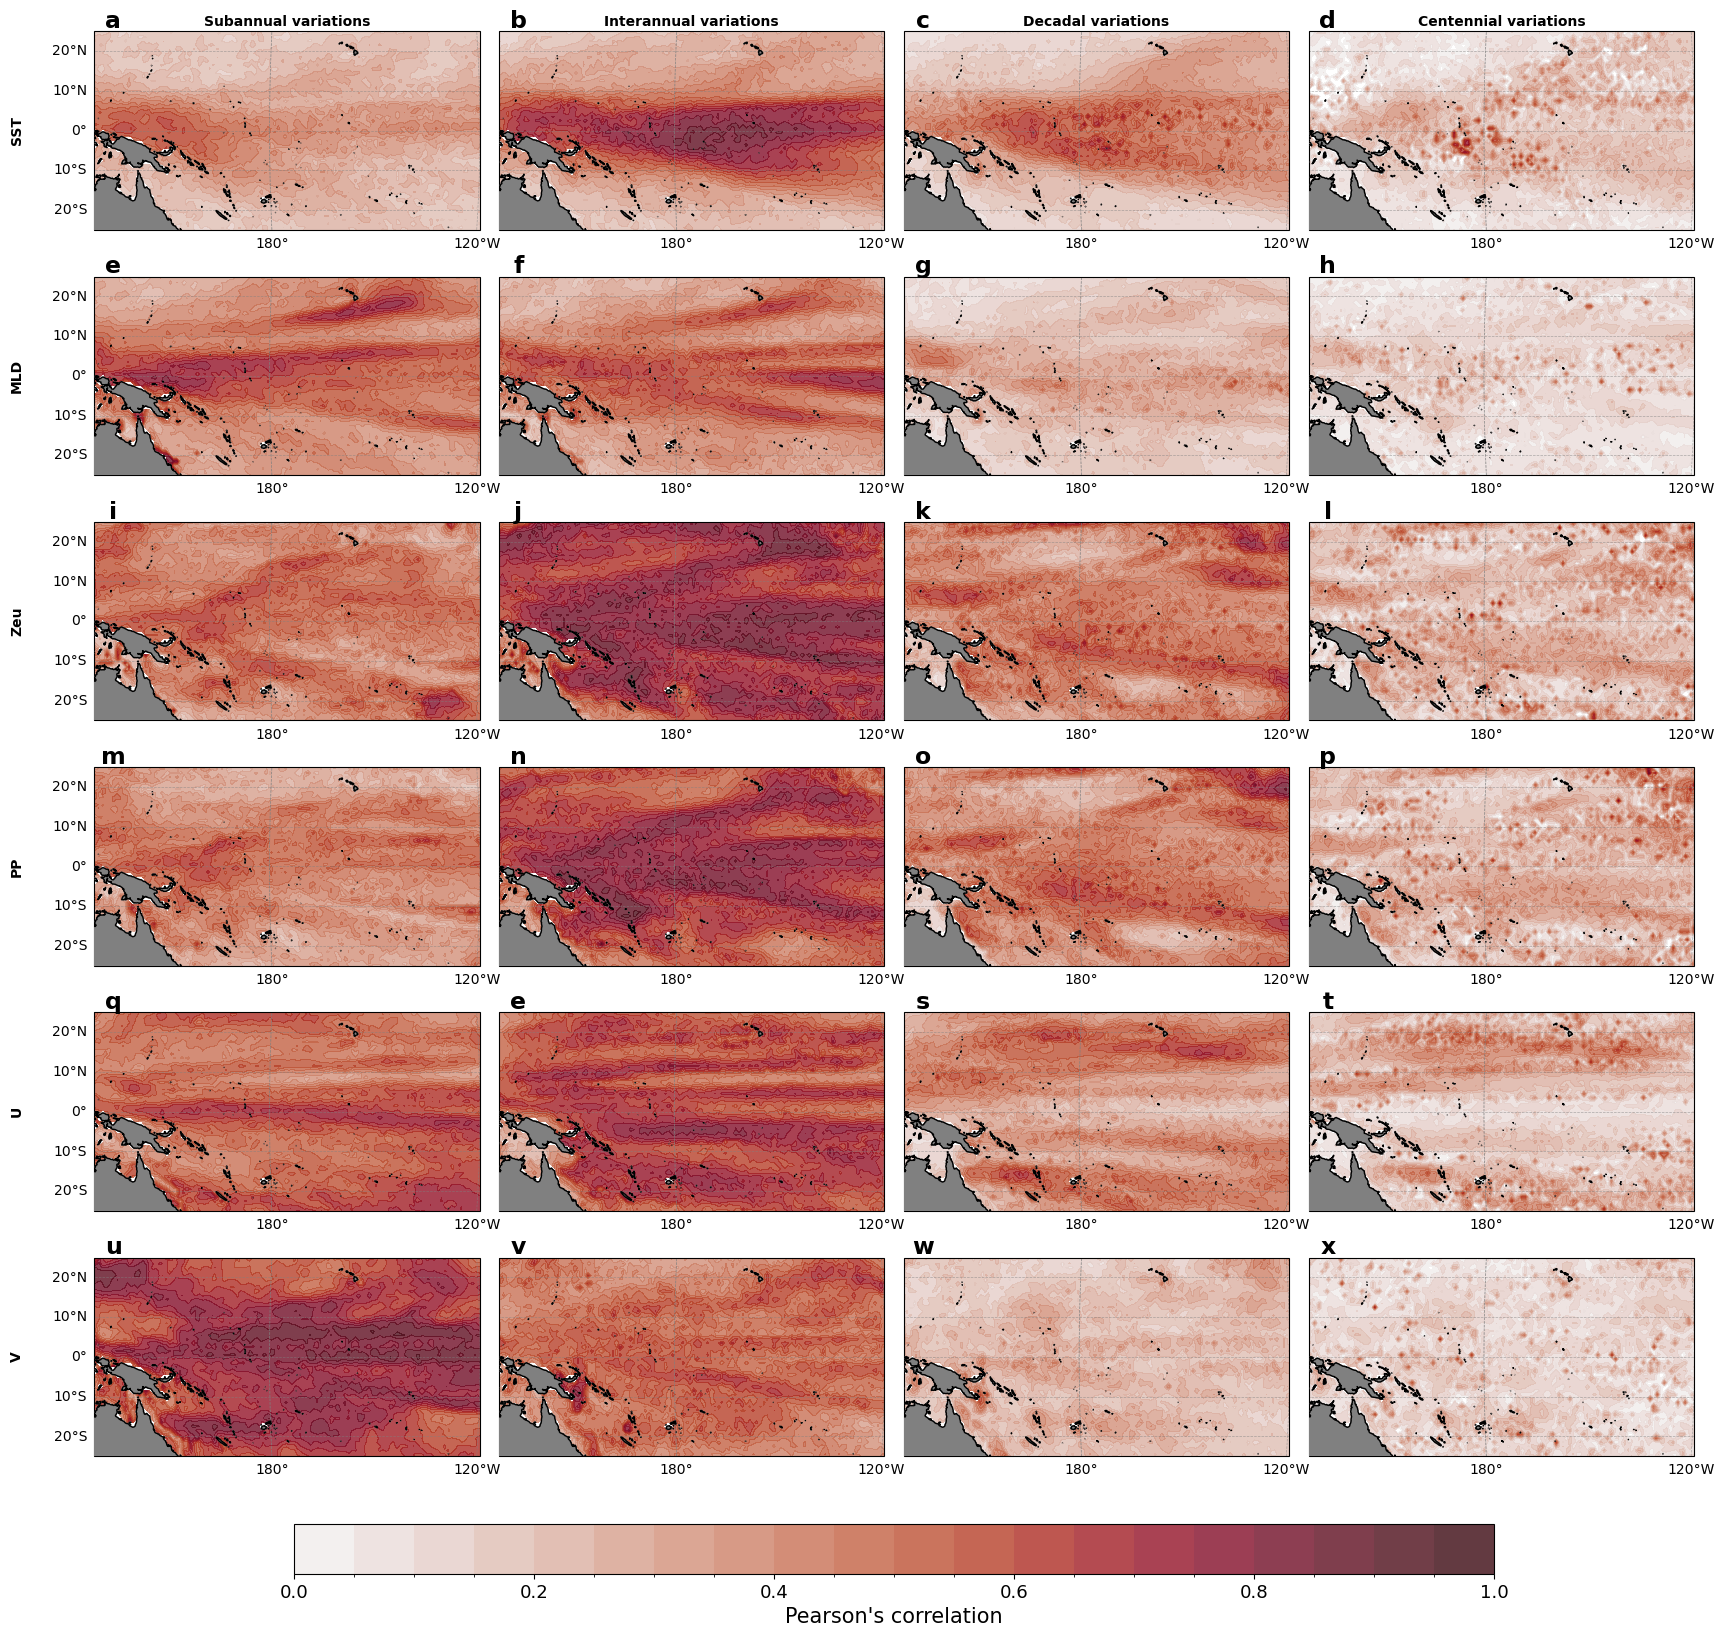

In [8]:
%%time

fslab = 15
fstic = 13

import matplotlib.lines as mlines
from cartopy.util import add_cyclic_point

proj = ccrs.Robinson(central_longitude=205)

colmap = lighten(cmo.amp, 0.8)
levs = np.arange(0.0,1.01,0.05)
norm = mcolors.BoundaryNorm(levs, ncolors=256)


fig = plt.figure(figsize=(20,20))
gs = GridSpec(6, 4)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[0,2], projection=proj)
ax4 = plt.subplot(gs[0,3], projection=proj)
ax5 = plt.subplot(gs[1,0], projection=proj)
ax6 = plt.subplot(gs[1,1], projection=proj)
ax7 = plt.subplot(gs[1,2], projection=proj)
ax8 = plt.subplot(gs[1,3], projection=proj)
ax9 = plt.subplot(gs[2,0], projection=proj)
ax10 = plt.subplot(gs[2,1], projection=proj)
ax11 = plt.subplot(gs[2,2], projection=proj)
ax12 = plt.subplot(gs[2,3], projection=proj)
ax13 = plt.subplot(gs[3,0], projection=proj)
ax14 = plt.subplot(gs[3,1], projection=proj)
ax15 = plt.subplot(gs[3,2], projection=proj)
ax16 = plt.subplot(gs[3,3], projection=proj)
ax17 = plt.subplot(gs[4,0], projection=proj)
ax18 = plt.subplot(gs[4,1], projection=proj)
ax19 = plt.subplot(gs[4,2], projection=proj)
ax20 = plt.subplot(gs[4,3], projection=proj)
ax21 = plt.subplot(gs[5,0], projection=proj)
ax22 = plt.subplot(gs[5,1], projection=proj)
ax23 = plt.subplot(gs[5,2], projection=proj)
ax24 = plt.subplot(gs[5,3], projection=proj)


p1 = ax1.contourf(lons, lats, r_sst_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p2 = ax2.contourf(lons, lats, r_sst_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p3 = ax3.contourf(lons, lats, r_sst_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p4 = ax4.contourf(lons, lats, r_sst_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p5 = ax5.contourf(lons, lats, r_mld_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p6 = ax6.contourf(lons, lats, r_mld_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p7 = ax7.contourf(lons, lats, r_mld_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p8 = ax8.contourf(lons, lats, r_mld_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p9 = ax9.contourf(lons, lats, r_zeu_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p10 = ax10.contourf(lons, lats, r_zeu_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p11 = ax11.contourf(lons, lats, r_zeu_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p12 = ax12.contourf(lons, lats, r_zeu_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p13 = ax13.contourf(lons, lats, r_pp_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p14 = ax14.contourf(lons, lats, r_pp_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p15 = ax15.contourf(lons, lats, r_pp_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p16 = ax16.contourf(lons, lats, r_pp_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p17 = ax17.contourf(lons, lats, r_uo_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p18 = ax18.contourf(lons, lats, r_uo_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p19 = ax19.contourf(lons, lats, r_uo_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p20 = ax20.contourf(lons, lats, r_uo_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p21 = ax21.contourf(lons, lats, r_vo_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p22 = ax22.contourf(lons, lats, r_vo_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p23 = ax23.contourf(lons, lats, r_vo_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p24 = ax24.contourf(lons, lats, r_vo_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')


ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax7.add_feature(cfeature.LAND, color='grey', zorder=3)
ax7.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax8.add_feature(cfeature.LAND, color='grey', zorder=3)
ax8.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax9.add_feature(cfeature.LAND, color='grey', zorder=3)
ax9.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax10.add_feature(cfeature.LAND, color='grey', zorder=3)
ax10.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax11.add_feature(cfeature.LAND, color='grey', zorder=3)
ax11.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax12.add_feature(cfeature.LAND, color='grey', zorder=3)
ax12.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax13.add_feature(cfeature.LAND, color='grey', zorder=3)
ax13.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax14.add_feature(cfeature.LAND, color='grey', zorder=3)
ax14.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax15.add_feature(cfeature.LAND, color='grey', zorder=3)
ax15.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax16.add_feature(cfeature.LAND, color='grey', zorder=3)
ax16.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax17.add_feature(cfeature.LAND, color='grey', zorder=3)
ax17.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax18.add_feature(cfeature.LAND, color='grey', zorder=3)
ax18.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax19.add_feature(cfeature.LAND, color='grey', zorder=3)
ax19.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax20.add_feature(cfeature.LAND, color='grey', zorder=3)
ax20.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax21.add_feature(cfeature.LAND, color='grey', zorder=3)
ax21.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax22.add_feature(cfeature.LAND, color='grey', zorder=3)
ax22.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax23.add_feature(cfeature.LAND, color='grey', zorder=3)
ax23.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax24.add_feature(cfeature.LAND, color='grey', zorder=3)
ax24.add_feature(cfeature.COASTLINE, color='k', zorder=4)

xx = 0.5; yy = 1.05
plt.text(xx,yy, 'Subannual variations', ha='center', va='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy, 'Interannual variations', ha='center', va='center', fontweight='bold', transform=ax2.transAxes)
plt.text(xx,yy, 'Decadal variations', ha='center', va='center', fontweight='bold', transform=ax3.transAxes)
plt.text(xx,yy, 'Centennial variations', ha='center', va='center', fontweight='bold', transform=ax4.transAxes)


xx = -0.2; yy = 0.5
plt.text(xx,yy, 'SST', ha='center', va='center', fontweight='bold', transform=ax1.transAxes, rotation=90)
plt.text(xx,yy, 'MLD', ha='center', va='center', fontweight='bold', transform=ax5.transAxes, rotation=90)
plt.text(xx,yy, 'Zeu', ha='center', va='center', fontweight='bold', transform=ax9.transAxes, rotation=90)
plt.text(xx,yy, 'PP', ha='center', va='center', fontweight='bold', transform=ax13.transAxes, rotation=90)
plt.text(xx,yy, 'U', ha='center', va='center', fontweight='bold', transform=ax17.transAxes, rotation=90)
plt.text(xx,yy, 'V', ha='center', va='center', fontweight='bold', transform=ax21.transAxes, rotation=90)

xx = 0.05
yy = 1.05
plt.text(xx,yy, 'a', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy, 'b', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy, 'c', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy, 'd', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy, 'e', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy, 'f', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax6.transAxes)
plt.text(xx,yy, 'g', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax7.transAxes)
plt.text(xx,yy, 'h', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax8.transAxes)
plt.text(xx,yy, 'i', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax9.transAxes)
plt.text(xx,yy, 'j', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax10.transAxes)
plt.text(xx,yy, 'k', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax11.transAxes)
plt.text(xx,yy, 'l', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax12.transAxes)
plt.text(xx,yy, 'm', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax13.transAxes)
plt.text(xx,yy, 'n', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax14.transAxes)
plt.text(xx,yy, 'o', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax15.transAxes)
plt.text(xx,yy, 'p', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax16.transAxes)
plt.text(xx,yy, 'q', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax17.transAxes)
plt.text(xx,yy, 'e', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax18.transAxes)
plt.text(xx,yy, 's', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax19.transAxes)
plt.text(xx,yy, 't', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax20.transAxes)
plt.text(xx,yy, 'u', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax21.transAxes)
plt.text(xx,yy, 'v', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax22.transAxes)
plt.text(xx,yy, 'w', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax23.transAxes)
plt.text(xx,yy, 'x', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax24.transAxes)

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl7 = ax7.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl8 = ax8.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl9 = ax9.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl10 = ax10.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl11 = ax11.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl12 = ax12.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl13 = ax13.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl14 = ax14.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl15 = ax15.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl16 = ax16.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl17 = ax17.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl18 = ax18.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl19 = ax19.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl20 = ax20.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl21 = ax21.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl22 = ax22.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl23 = ax23.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl24 = ax24.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False; gl3.left_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.left_labels = False
gl7.top_labels = False; gl7.right_labels = False; gl7.left_labels = False
gl8.top_labels = False; gl8.right_labels = False; gl8.left_labels = False
gl9.top_labels = False; gl9.right_labels = False
gl10.top_labels = False; gl10.right_labels = False; gl10.left_labels = False
gl11.top_labels = False; gl11.right_labels = False; gl11.left_labels = False
gl12.top_labels = False; gl12.right_labels = False; gl12.left_labels = False
gl13.top_labels = False; gl13.right_labels = False
gl14.top_labels = False; gl14.right_labels = False; gl14.left_labels = False
gl15.top_labels = False; gl15.right_labels = False; gl15.left_labels = False
gl16.top_labels = False; gl16.right_labels = False; gl16.left_labels = False
gl17.top_labels = False; gl17.right_labels = False
gl18.top_labels = False; gl18.right_labels = False; gl18.left_labels = False
gl19.top_labels = False; gl19.right_labels = False; gl19.left_labels = False
gl20.top_labels = False; gl20.right_labels = False; gl20.left_labels = False
gl21.top_labels = False; gl21.right_labels = False
gl22.top_labels = False; gl22.right_labels = False; gl22.left_labels = False
gl23.top_labels = False; gl23.right_labels = False; gl23.left_labels = False
gl24.top_labels = False; gl24.right_labels = False; gl24.left_labels = False

ax1.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax2.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax3.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax4.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax5.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax6.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax7.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax8.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax9.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax10.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax11.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax12.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax13.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax14.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax15.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax16.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax17.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax18.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax19.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax20.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax21.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax22.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax23.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax24.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.1, right=0.9, bottom=0.15)

cbax1 = fig.add_axes([0.2,0.1,0.6,0.025])
cbar1 = plt.colorbar(p1, cax=cbax1, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_xlabel("Pearson's correlation", fontsize=fslab)


In [9]:
fig.savefig("./pearse_GAMs/figures/IMFs_correlation_sst_mld_zeu_pp_uo_vo.png", dpi=300)

CPU times: user 3min 21s, sys: 122 ms, total: 3min 21s
Wall time: 3min 21s


/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(0.5, 0, "Pearson's correlation")

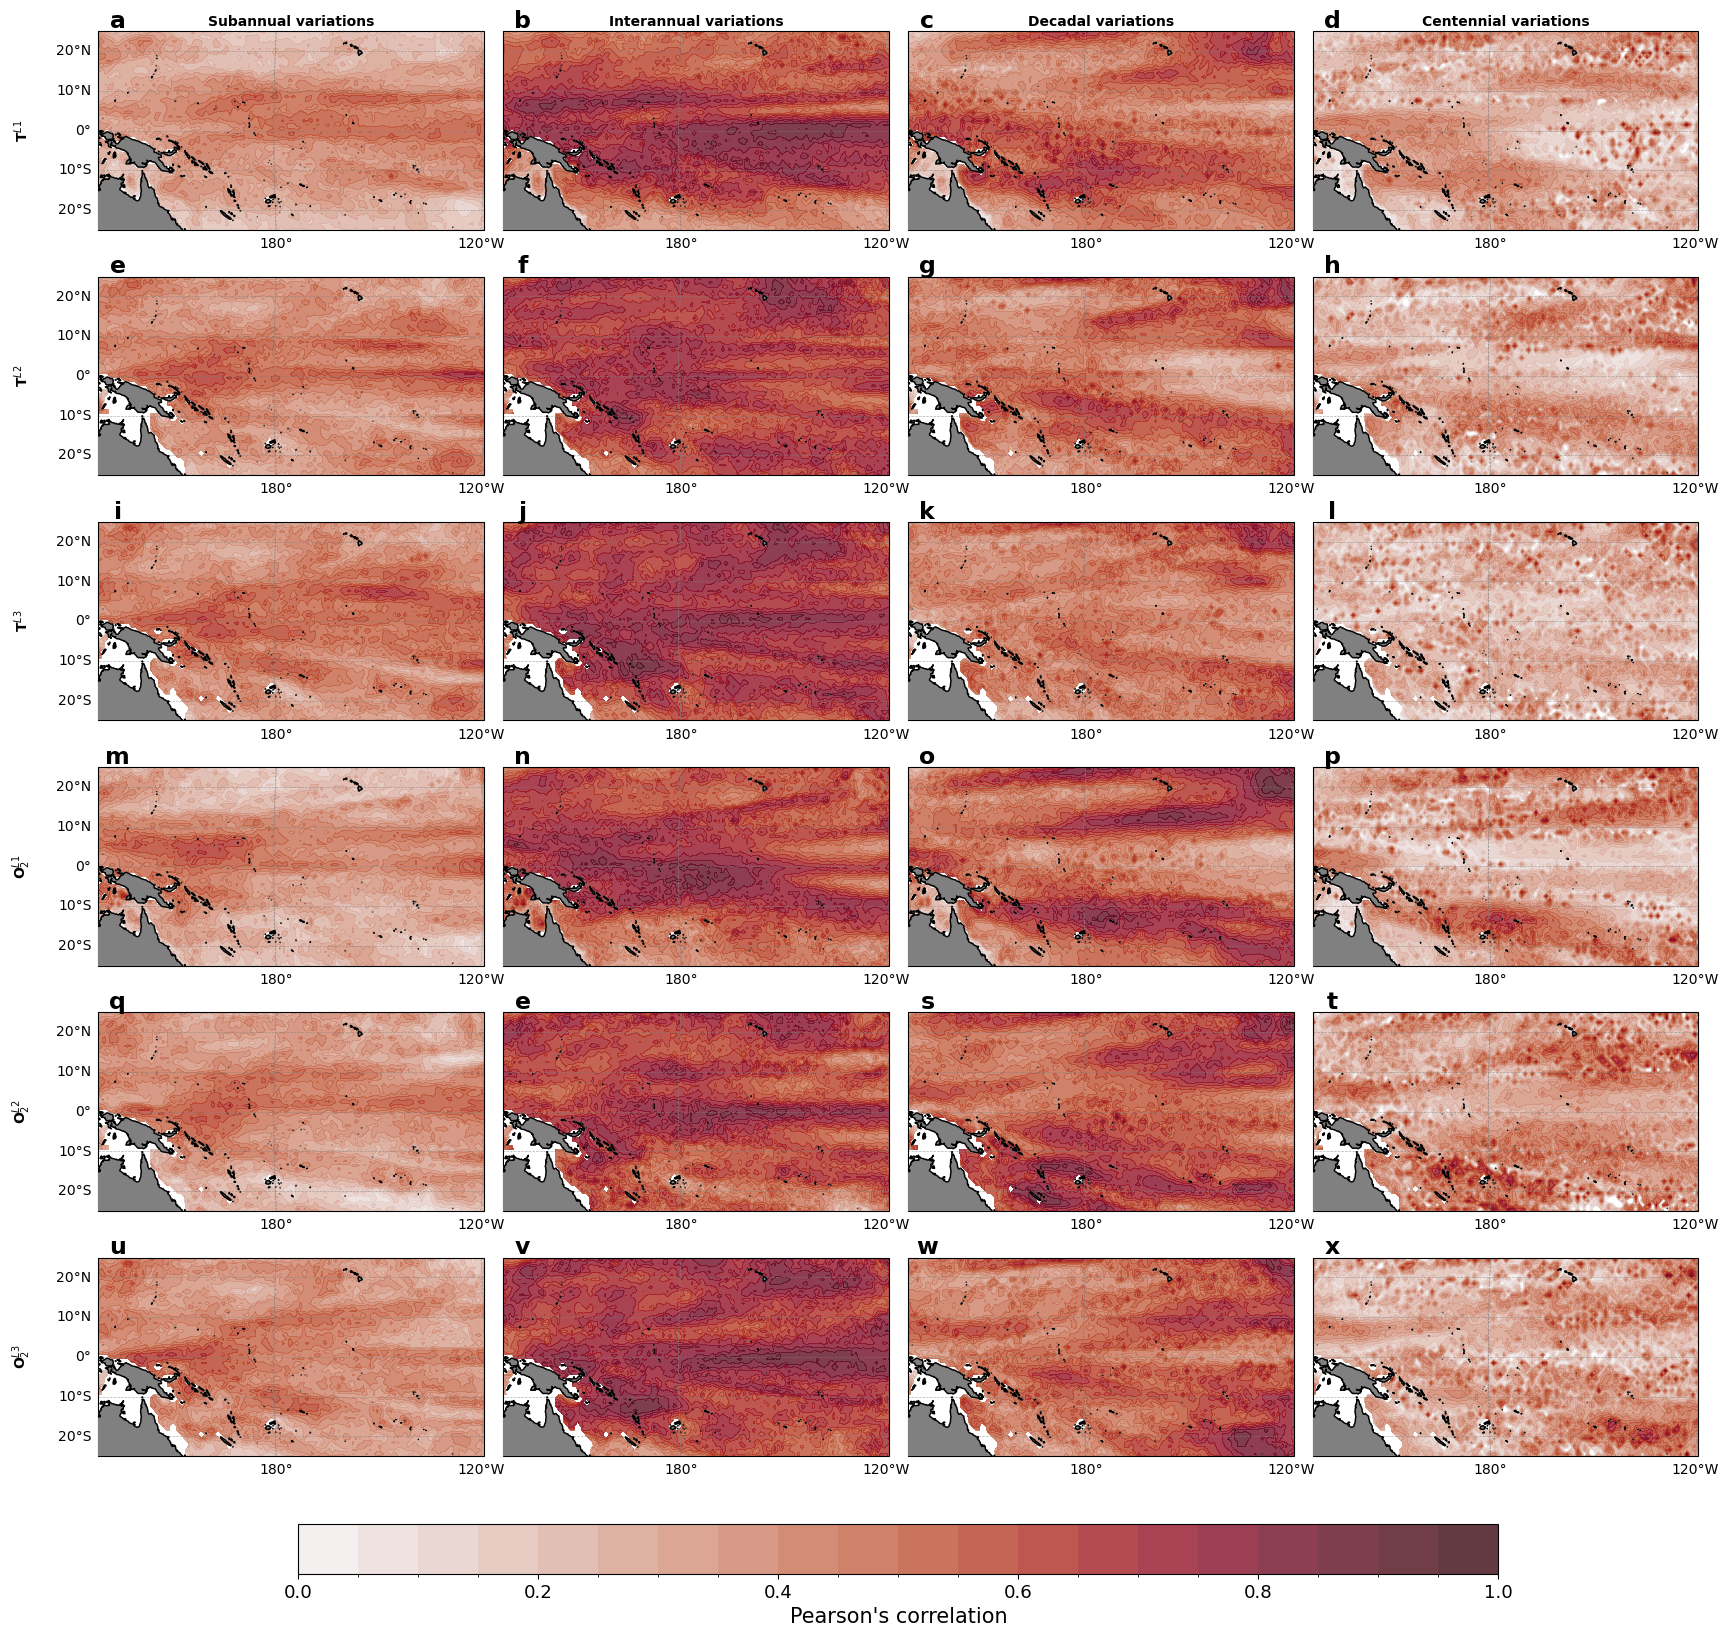

In [10]:
%%time

fslab = 15
fstic = 13

import matplotlib.lines as mlines
from cartopy.util import add_cyclic_point

proj = ccrs.Robinson(central_longitude=205)

colmap = lighten(cmo.amp, 0.8)
levs = np.arange(-0.0,1.01,0.05)
norm = mcolors.BoundaryNorm(levs, ncolors=256)


fig = plt.figure(figsize=(20,20))
gs = GridSpec(6, 4)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[0,2], projection=proj)
ax4 = plt.subplot(gs[0,3], projection=proj)
ax5 = plt.subplot(gs[1,0], projection=proj)
ax6 = plt.subplot(gs[1,1], projection=proj)
ax7 = plt.subplot(gs[1,2], projection=proj)
ax8 = plt.subplot(gs[1,3], projection=proj)
ax9 = plt.subplot(gs[2,0], projection=proj)
ax10 = plt.subplot(gs[2,1], projection=proj)
ax11 = plt.subplot(gs[2,2], projection=proj)
ax12 = plt.subplot(gs[2,3], projection=proj)
ax13 = plt.subplot(gs[3,0], projection=proj)
ax14 = plt.subplot(gs[3,1], projection=proj)
ax15 = plt.subplot(gs[3,2], projection=proj)
ax16 = plt.subplot(gs[3,3], projection=proj)
ax17 = plt.subplot(gs[4,0], projection=proj)
ax18 = plt.subplot(gs[4,1], projection=proj)
ax19 = plt.subplot(gs[4,2], projection=proj)
ax20 = plt.subplot(gs[4,3], projection=proj)
ax21 = plt.subplot(gs[5,0], projection=proj)
ax22 = plt.subplot(gs[5,1], projection=proj)
ax23 = plt.subplot(gs[5,2], projection=proj)
ax24 = plt.subplot(gs[5,3], projection=proj)

p1 = ax1.contourf(lons, lats, r_T_L1_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p2 = ax2.contourf(lons, lats, r_T_L1_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p3 = ax3.contourf(lons, lats, r_T_L1_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p4 = ax4.contourf(lons, lats, r_T_L1_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p5 = ax5.contourf(lons, lats, r_T_L2_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p6 = ax6.contourf(lons, lats, r_T_L2_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p7 = ax7.contourf(lons, lats, r_T_L2_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p8 = ax8.contourf(lons, lats, r_T_L2_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p9 = ax9.contourf(lons, lats, r_T_L3_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p10 = ax10.contourf(lons, lats, r_T_L3_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p11 = ax11.contourf(lons, lats, r_T_L3_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p12 = ax12.contourf(lons, lats, r_T_L3_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p13 = ax13.contourf(lons, lats, r_O2_L1_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p14 = ax14.contourf(lons, lats, r_O2_L1_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p15 = ax15.contourf(lons, lats, r_O2_L1_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p16 = ax16.contourf(lons, lats, r_O2_L1_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p17 = ax17.contourf(lons, lats, r_O2_L2_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p18 = ax18.contourf(lons, lats, r_O2_L2_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p19 = ax19.contourf(lons, lats, r_O2_L2_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p20 = ax20.contourf(lons, lats, r_O2_L2_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p21 = ax21.contourf(lons, lats, r_O2_L3_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p22 = ax22.contourf(lons, lats, r_O2_L3_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p23 = ax23.contourf(lons, lats, r_O2_L3_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p24 = ax24.contourf(lons, lats, r_O2_L3_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')


ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax7.add_feature(cfeature.LAND, color='grey', zorder=3)
ax7.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax8.add_feature(cfeature.LAND, color='grey', zorder=3)
ax8.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax9.add_feature(cfeature.LAND, color='grey', zorder=3)
ax9.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax10.add_feature(cfeature.LAND, color='grey', zorder=3)
ax10.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax11.add_feature(cfeature.LAND, color='grey', zorder=3)
ax11.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax12.add_feature(cfeature.LAND, color='grey', zorder=3)
ax12.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax13.add_feature(cfeature.LAND, color='grey', zorder=3)
ax13.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax14.add_feature(cfeature.LAND, color='grey', zorder=3)
ax14.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax15.add_feature(cfeature.LAND, color='grey', zorder=3)
ax15.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax16.add_feature(cfeature.LAND, color='grey', zorder=3)
ax16.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax17.add_feature(cfeature.LAND, color='grey', zorder=3)
ax17.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax18.add_feature(cfeature.LAND, color='grey', zorder=3)
ax18.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax19.add_feature(cfeature.LAND, color='grey', zorder=3)
ax19.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax20.add_feature(cfeature.LAND, color='grey', zorder=3)
ax20.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax21.add_feature(cfeature.LAND, color='grey', zorder=3)
ax21.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax22.add_feature(cfeature.LAND, color='grey', zorder=3)
ax22.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax23.add_feature(cfeature.LAND, color='grey', zorder=3)
ax23.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax24.add_feature(cfeature.LAND, color='grey', zorder=3)
ax24.add_feature(cfeature.COASTLINE, color='k', zorder=4)

xx = 0.5; yy = 1.05
plt.text(xx,yy, 'Subannual variations', ha='center', va='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy, 'Interannual variations', ha='center', va='center', fontweight='bold', transform=ax2.transAxes)
plt.text(xx,yy, 'Decadal variations', ha='center', va='center', fontweight='bold', transform=ax3.transAxes)
plt.text(xx,yy, 'Centennial variations', ha='center', va='center', fontweight='bold', transform=ax4.transAxes)

xx = -0.2; yy = 0.5
plt.text(xx,yy, 'T$^{L1}$', ha='center', va='center', fontweight='bold', transform=ax1.transAxes, rotation=90)
plt.text(xx,yy, 'T$^{L2}$', ha='center', va='center', fontweight='bold', transform=ax5.transAxes, rotation=90)
plt.text(xx,yy, 'T$^{L3}$', ha='center', va='center', fontweight='bold', transform=ax9.transAxes, rotation=90)
plt.text(xx,yy, 'O$_{2}^{L1}$', ha='center', va='center', fontweight='bold', transform=ax13.transAxes, rotation=90)
plt.text(xx,yy, 'O$_{2}^{L2}$', ha='center', va='center', fontweight='bold', transform=ax17.transAxes, rotation=90)
plt.text(xx,yy, 'O$_{2}^{L3}$', ha='center', va='center', fontweight='bold', transform=ax21.transAxes, rotation=90)

xx = 0.05
yy = 1.05
plt.text(xx,yy, 'a', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy, 'b', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy, 'c', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy, 'd', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy, 'e', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy, 'f', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax6.transAxes)
plt.text(xx,yy, 'g', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax7.transAxes)
plt.text(xx,yy, 'h', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax8.transAxes)
plt.text(xx,yy, 'i', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax9.transAxes)
plt.text(xx,yy, 'j', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax10.transAxes)
plt.text(xx,yy, 'k', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax11.transAxes)
plt.text(xx,yy, 'l', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax12.transAxes)
plt.text(xx,yy, 'm', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax13.transAxes)
plt.text(xx,yy, 'n', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax14.transAxes)
plt.text(xx,yy, 'o', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax15.transAxes)
plt.text(xx,yy, 'p', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax16.transAxes)
plt.text(xx,yy, 'q', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax17.transAxes)
plt.text(xx,yy, 'e', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax18.transAxes)
plt.text(xx,yy, 's', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax19.transAxes)
plt.text(xx,yy, 't', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax20.transAxes)
plt.text(xx,yy, 'u', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax21.transAxes)
plt.text(xx,yy, 'v', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax22.transAxes)
plt.text(xx,yy, 'w', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax23.transAxes)
plt.text(xx,yy, 'x', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax24.transAxes)

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl7 = ax7.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl8 = ax8.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl9 = ax9.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl10 = ax10.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl11 = ax11.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl12 = ax12.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl13 = ax13.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl14 = ax14.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl15 = ax15.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl16 = ax16.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl17 = ax17.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl18 = ax18.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl19 = ax19.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl20 = ax20.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl21 = ax21.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl22 = ax22.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl23 = ax23.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl24 = ax24.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False; gl3.left_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.left_labels = False
gl7.top_labels = False; gl7.right_labels = False; gl7.left_labels = False
gl8.top_labels = False; gl8.right_labels = False; gl8.left_labels = False
gl9.top_labels = False; gl9.right_labels = False
gl10.top_labels = False; gl10.right_labels = False; gl10.left_labels = False
gl11.top_labels = False; gl11.right_labels = False; gl11.left_labels = False
gl12.top_labels = False; gl12.right_labels = False; gl12.left_labels = False
gl13.top_labels = False; gl13.right_labels = False
gl14.top_labels = False; gl14.right_labels = False; gl14.left_labels = False
gl15.top_labels = False; gl15.right_labels = False; gl15.left_labels = False
gl16.top_labels = False; gl16.right_labels = False; gl16.left_labels = False
gl17.top_labels = False; gl17.right_labels = False
gl18.top_labels = False; gl18.right_labels = False; gl18.left_labels = False
gl19.top_labels = False; gl19.right_labels = False; gl19.left_labels = False
gl20.top_labels = False; gl20.right_labels = False; gl20.left_labels = False
gl21.top_labels = False; gl21.right_labels = False
gl22.top_labels = False; gl22.right_labels = False; gl22.left_labels = False
gl23.top_labels = False; gl23.right_labels = False; gl23.left_labels = False
gl24.top_labels = False; gl24.right_labels = False; gl24.left_labels = False

ax1.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax2.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax3.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax4.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax5.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax6.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax7.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax8.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax9.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax10.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax11.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax12.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax13.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax14.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax15.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax16.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax17.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax18.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax19.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax20.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax21.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax22.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax23.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax24.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.1, right=0.9, bottom=0.15)

cbax1 = fig.add_axes([0.2,0.1,0.6,0.025])
cbar1 = plt.colorbar(p1, cax=cbax1, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_xlabel("Pearson's correlation", fontsize=fslab)


In [11]:
fig.savefig("./pearse_GAMs/figures/IMFs_correlation_TL1_TL2_TL3_O2L1_O2L2_O2L3.png", dpi=300)

CPU times: user 3min 26s, sys: 111 ms, total: 3min 26s
Wall time: 3min 26s


/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(0.5, 0, "Pearson's correlation")

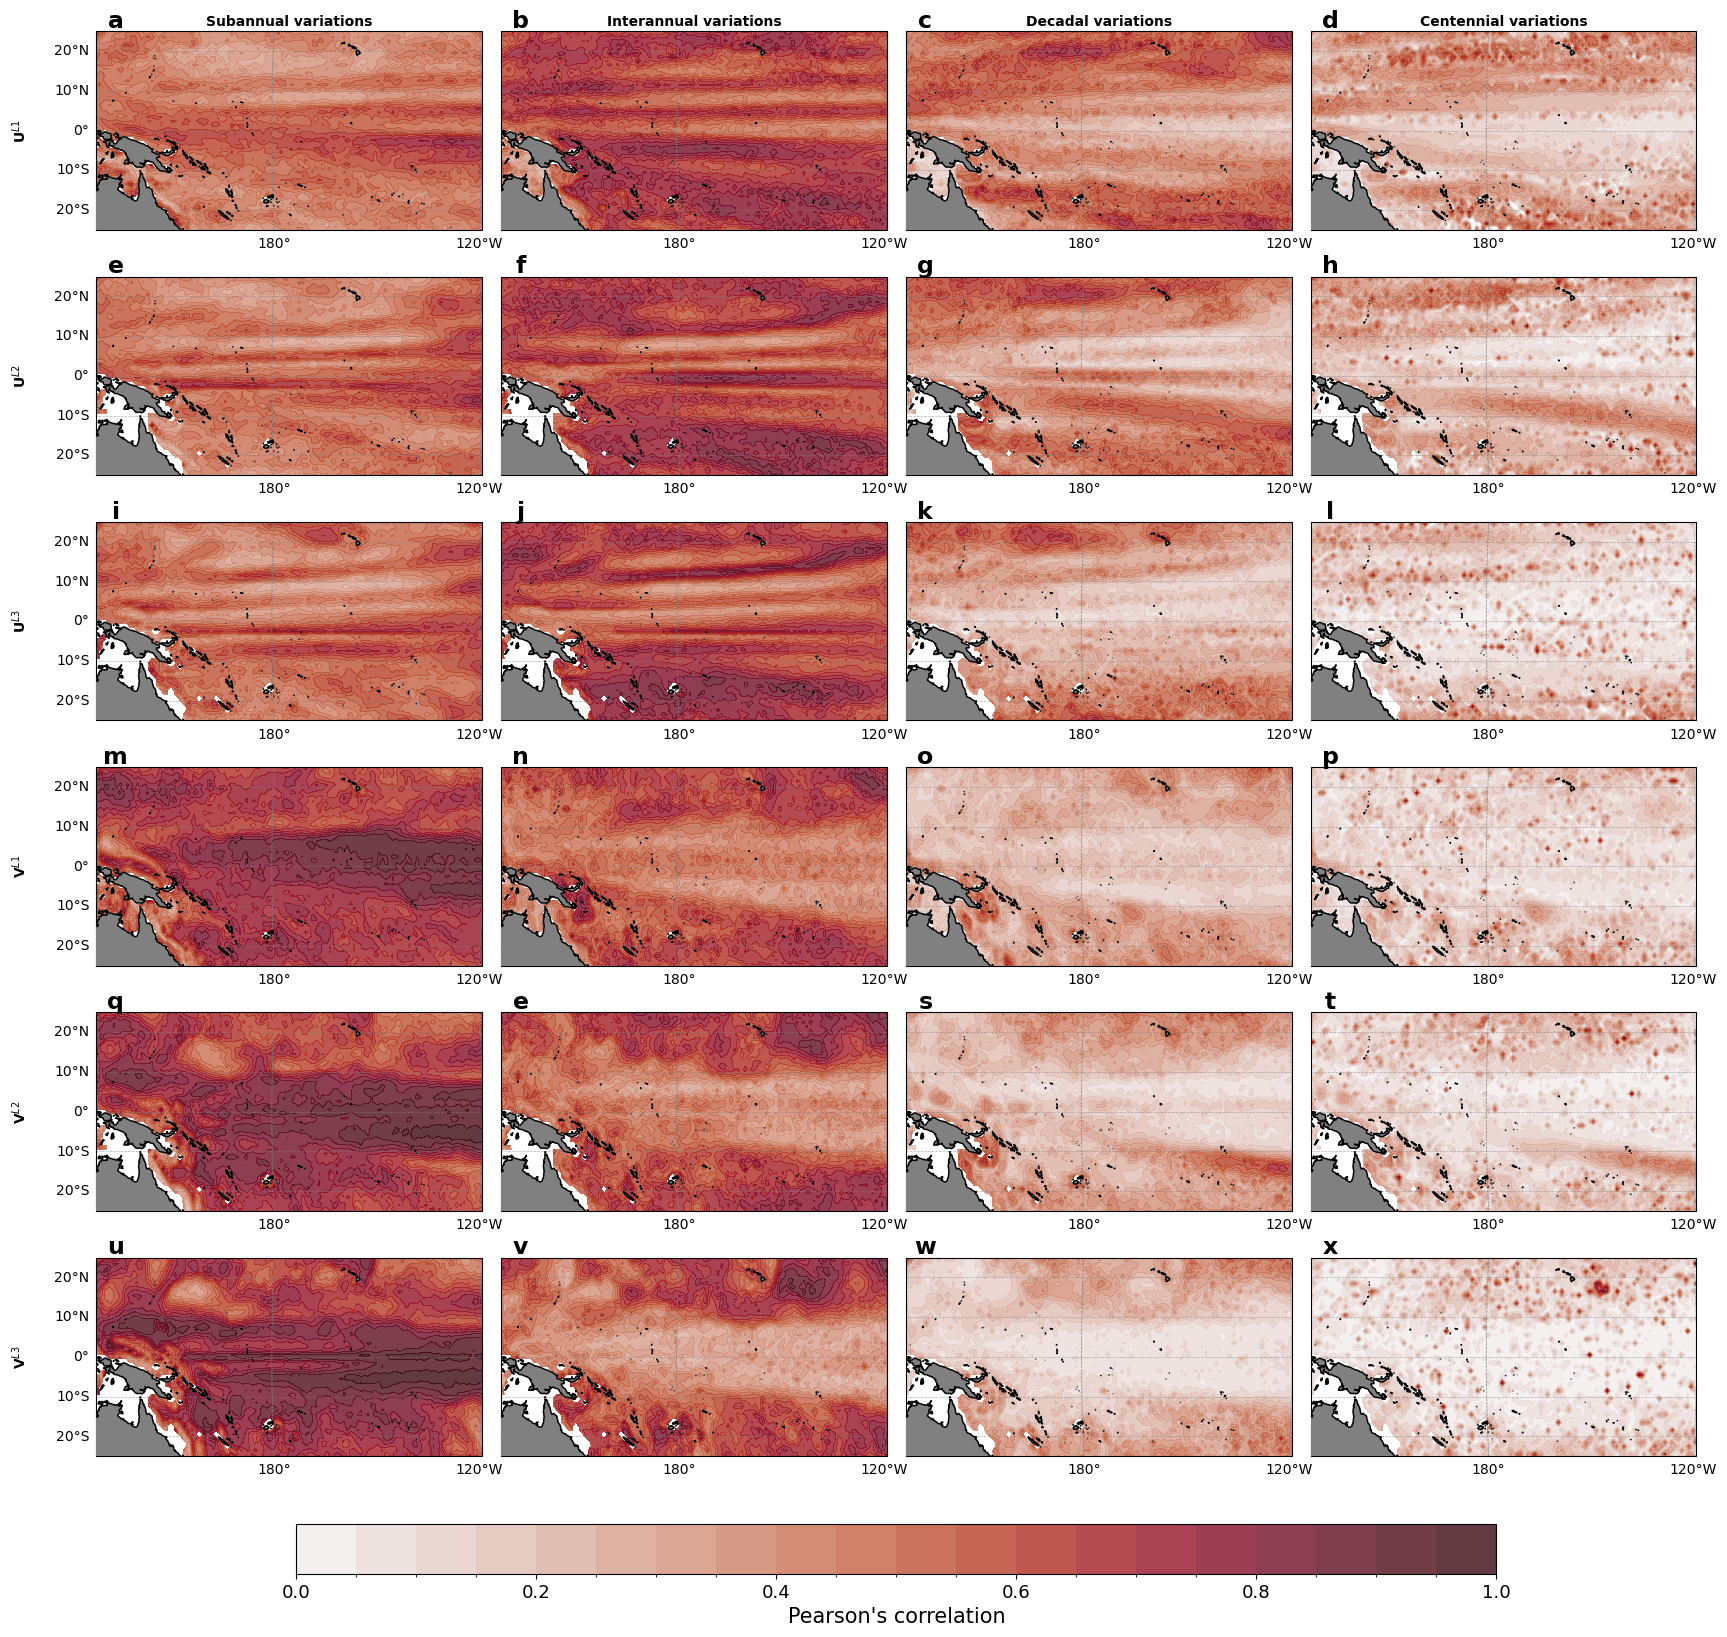

In [12]:
%%time

fslab = 15
fstic = 13

import matplotlib.lines as mlines
from cartopy.util import add_cyclic_point

proj = ccrs.Robinson(central_longitude=205)

colmap = lighten(cmo.amp, 0.8)
levs = np.arange(-0.0,1.01,0.05)
norm = mcolors.BoundaryNorm(levs, ncolors=256)


fig = plt.figure(figsize=(20,20))
gs = GridSpec(6, 4)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[0,2], projection=proj)
ax4 = plt.subplot(gs[0,3], projection=proj)
ax5 = plt.subplot(gs[1,0], projection=proj)
ax6 = plt.subplot(gs[1,1], projection=proj)
ax7 = plt.subplot(gs[1,2], projection=proj)
ax8 = plt.subplot(gs[1,3], projection=proj)
ax9 = plt.subplot(gs[2,0], projection=proj)
ax10 = plt.subplot(gs[2,1], projection=proj)
ax11 = plt.subplot(gs[2,2], projection=proj)
ax12 = plt.subplot(gs[2,3], projection=proj)
ax13 = plt.subplot(gs[3,0], projection=proj)
ax14 = plt.subplot(gs[3,1], projection=proj)
ax15 = plt.subplot(gs[3,2], projection=proj)
ax16 = plt.subplot(gs[3,3], projection=proj)
ax17 = plt.subplot(gs[4,0], projection=proj)
ax18 = plt.subplot(gs[4,1], projection=proj)
ax19 = plt.subplot(gs[4,2], projection=proj)
ax20 = plt.subplot(gs[4,3], projection=proj)
ax21 = plt.subplot(gs[5,0], projection=proj)
ax22 = plt.subplot(gs[5,1], projection=proj)
ax23 = plt.subplot(gs[5,2], projection=proj)
ax24 = plt.subplot(gs[5,3], projection=proj)

p1 = ax1.contourf(lons, lats, r_U_L1_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p2 = ax2.contourf(lons, lats, r_U_L1_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p3 = ax3.contourf(lons, lats, r_U_L1_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p4 = ax4.contourf(lons, lats, r_U_L1_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p5 = ax5.contourf(lons, lats, r_U_L2_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p6 = ax6.contourf(lons, lats, r_U_L2_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p7 = ax7.contourf(lons, lats, r_U_L2_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p8 = ax8.contourf(lons, lats, r_U_L2_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p9 = ax9.contourf(lons, lats, r_U_L3_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p10 = ax10.contourf(lons, lats, r_U_L3_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p11 = ax11.contourf(lons, lats, r_U_L3_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p12 = ax12.contourf(lons, lats, r_U_L3_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p13 = ax13.contourf(lons, lats, r_V_L1_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p14 = ax14.contourf(lons, lats, r_V_L1_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p15 = ax15.contourf(lons, lats, r_V_L1_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p16 = ax16.contourf(lons, lats, r_V_L1_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p17 = ax17.contourf(lons, lats, r_V_L2_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p18 = ax18.contourf(lons, lats, r_V_L2_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p19 = ax19.contourf(lons, lats, r_V_L2_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p20 = ax20.contourf(lons, lats, r_V_L2_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p21 = ax21.contourf(lons, lats, r_V_L3_HF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p22 = ax22.contourf(lons, lats, r_V_L3_MF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p23 = ax23.contourf(lons, lats, r_V_L3_LF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')
p24 = ax24.contourf(lons, lats, r_V_L3_VLF, transform=ccrs.PlateCarree(), cmap=colmap, norm=norm, levels=levs, extend='neither')


ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax7.add_feature(cfeature.LAND, color='grey', zorder=3)
ax7.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax8.add_feature(cfeature.LAND, color='grey', zorder=3)
ax8.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax9.add_feature(cfeature.LAND, color='grey', zorder=3)
ax9.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax10.add_feature(cfeature.LAND, color='grey', zorder=3)
ax10.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax11.add_feature(cfeature.LAND, color='grey', zorder=3)
ax11.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax12.add_feature(cfeature.LAND, color='grey', zorder=3)
ax12.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax13.add_feature(cfeature.LAND, color='grey', zorder=3)
ax13.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax14.add_feature(cfeature.LAND, color='grey', zorder=3)
ax14.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax15.add_feature(cfeature.LAND, color='grey', zorder=3)
ax15.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax16.add_feature(cfeature.LAND, color='grey', zorder=3)
ax16.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax17.add_feature(cfeature.LAND, color='grey', zorder=3)
ax17.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax18.add_feature(cfeature.LAND, color='grey', zorder=3)
ax18.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax19.add_feature(cfeature.LAND, color='grey', zorder=3)
ax19.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax20.add_feature(cfeature.LAND, color='grey', zorder=3)
ax20.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax21.add_feature(cfeature.LAND, color='grey', zorder=3)
ax21.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax22.add_feature(cfeature.LAND, color='grey', zorder=3)
ax22.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax23.add_feature(cfeature.LAND, color='grey', zorder=3)
ax23.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax24.add_feature(cfeature.LAND, color='grey', zorder=3)
ax24.add_feature(cfeature.COASTLINE, color='k', zorder=4)

xx = 0.5; yy = 1.05
plt.text(xx,yy, 'Subannual variations', ha='center', va='center', fontweight='bold', transform=ax1.transAxes)
plt.text(xx,yy, 'Interannual variations', ha='center', va='center', fontweight='bold', transform=ax2.transAxes)
plt.text(xx,yy, 'Decadal variations', ha='center', va='center', fontweight='bold', transform=ax3.transAxes)
plt.text(xx,yy, 'Centennial variations', ha='center', va='center', fontweight='bold', transform=ax4.transAxes)

xx = -0.2; yy = 0.5
plt.text(xx,yy, 'U$^{L1}$', ha='center', va='center', fontweight='bold', transform=ax1.transAxes, rotation=90)
plt.text(xx,yy, 'U$^{L2}$', ha='center', va='center', fontweight='bold', transform=ax5.transAxes, rotation=90)
plt.text(xx,yy, 'U$^{L3}$', ha='center', va='center', fontweight='bold', transform=ax9.transAxes, rotation=90)
plt.text(xx,yy, 'V$^{L1}$', ha='center', va='center', fontweight='bold', transform=ax13.transAxes, rotation=90)
plt.text(xx,yy, 'V$^{L2}$', ha='center', va='center', fontweight='bold', transform=ax17.transAxes, rotation=90)
plt.text(xx,yy, 'V$^{L3}$', ha='center', va='center', fontweight='bold', transform=ax21.transAxes, rotation=90)

xx = 0.05
yy = 1.05
plt.text(xx,yy, 'a', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy, 'b', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy, 'c', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy, 'd', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy, 'e', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy, 'f', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax6.transAxes)
plt.text(xx,yy, 'g', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax7.transAxes)
plt.text(xx,yy, 'h', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax8.transAxes)
plt.text(xx,yy, 'i', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax9.transAxes)
plt.text(xx,yy, 'j', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax10.transAxes)
plt.text(xx,yy, 'k', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax11.transAxes)
plt.text(xx,yy, 'l', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax12.transAxes)
plt.text(xx,yy, 'm', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax13.transAxes)
plt.text(xx,yy, 'n', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax14.transAxes)
plt.text(xx,yy, 'o', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax15.transAxes)
plt.text(xx,yy, 'p', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax16.transAxes)
plt.text(xx,yy, 'q', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax17.transAxes)
plt.text(xx,yy, 'e', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax18.transAxes)
plt.text(xx,yy, 's', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax19.transAxes)
plt.text(xx,yy, 't', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax20.transAxes)
plt.text(xx,yy, 'u', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax21.transAxes)
plt.text(xx,yy, 'v', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax22.transAxes)
plt.text(xx,yy, 'w', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax23.transAxes)
plt.text(xx,yy, 'x', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax24.transAxes)

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl7 = ax7.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl8 = ax8.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl9 = ax9.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl10 = ax10.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl11 = ax11.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl12 = ax12.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl13 = ax13.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl14 = ax14.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl15 = ax15.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl16 = ax16.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl17 = ax17.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl18 = ax18.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl19 = ax19.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl20 = ax20.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl21 = ax21.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl22 = ax22.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl23 = ax23.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl24 = ax24.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False; gl3.left_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.left_labels = False
gl7.top_labels = False; gl7.right_labels = False; gl7.left_labels = False
gl8.top_labels = False; gl8.right_labels = False; gl8.left_labels = False
gl9.top_labels = False; gl9.right_labels = False
gl10.top_labels = False; gl10.right_labels = False; gl10.left_labels = False
gl11.top_labels = False; gl11.right_labels = False; gl11.left_labels = False
gl12.top_labels = False; gl12.right_labels = False; gl12.left_labels = False
gl13.top_labels = False; gl13.right_labels = False
gl14.top_labels = False; gl14.right_labels = False; gl14.left_labels = False
gl15.top_labels = False; gl15.right_labels = False; gl15.left_labels = False
gl16.top_labels = False; gl16.right_labels = False; gl16.left_labels = False
gl17.top_labels = False; gl17.right_labels = False
gl18.top_labels = False; gl18.right_labels = False; gl18.left_labels = False
gl19.top_labels = False; gl19.right_labels = False; gl19.left_labels = False
gl20.top_labels = False; gl20.right_labels = False; gl20.left_labels = False
gl21.top_labels = False; gl21.right_labels = False
gl22.top_labels = False; gl22.right_labels = False; gl22.left_labels = False
gl23.top_labels = False; gl23.right_labels = False; gl23.left_labels = False
gl24.top_labels = False; gl24.right_labels = False; gl24.left_labels = False

ax1.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax2.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax3.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax4.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax5.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax6.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax7.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax8.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax9.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax10.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax11.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax12.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax13.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax14.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax15.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax16.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax17.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax18.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax19.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax20.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax21.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax22.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax23.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax24.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.1, right=0.9, bottom=0.15)

cbax1 = fig.add_axes([0.2,0.1,0.6,0.025])
cbar1 = plt.colorbar(p1, cax=cbax1, orientation='horizontal', ticks=levs[::4])
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_xlabel("Pearson's correlation", fontsize=fslab)


In [18]:
fig.savefig("./pearse_GAMs/figures/IMFs_correlation_UL1_UL2_UL3_VL1_VL2_VL3.png", dpi=300)

## Prepare IMF dataframes for input to GAMs

In [19]:
%%time

sst_noHF = (sst - sst_imfs.isel(IMF=0)).drop_vars("IMF")
sst_noMF = (sst - sst_imfs.isel(IMF=1)).drop_vars("IMF")
sst_noLF = (sst - sst_imfs.isel(IMF=2)).drop_vars("IMF")
sst_noVLF = (sst - sst_imfs.isel(IMF=3)).drop_vars("IMF")
sst_noF = (sst - sst_imfs.sum(dim="IMF"))
mld_noHF = (mld - mld_imfs.isel(IMF=0)).drop_vars("IMF")
mld_noMF = (mld - mld_imfs.isel(IMF=1)).drop_vars("IMF")
mld_noLF = (mld - mld_imfs.isel(IMF=2)).drop_vars("IMF")
mld_noVLF = (mld - mld_imfs.isel(IMF=3)).drop_vars("IMF")
mld_noF = (mld - mld_imfs.sum(dim="IMF"))
zeu_noHF = (zeu - zeu_imfs.isel(IMF=0)).drop_vars("IMF")
zeu_noMF = (zeu - zeu_imfs.isel(IMF=1)).drop_vars("IMF")
zeu_noLF = (zeu - zeu_imfs.isel(IMF=2)).drop_vars("IMF")
zeu_noVLF = (zeu - zeu_imfs.isel(IMF=3)).drop_vars("IMF")
zeu_noF = (zeu - zeu_imfs.sum(dim="IMF"))
pp_noHF = (pp - pp_imfs.isel(IMF=0)).drop_vars("IMF")
pp_noMF = (pp - pp_imfs.isel(IMF=1)).drop_vars("IMF")
pp_noLF = (pp - pp_imfs.isel(IMF=2)).drop_vars("IMF")
pp_noVLF = (pp - pp_imfs.isel(IMF=3)).drop_vars("IMF")
pp_noF = (pp - pp_imfs.sum(dim="IMF"))
pp75_noHF = (pp75 - pp75_imfs.isel(IMF=0)).drop_vars("IMF")
pp75_noMF = (pp75 - pp75_imfs.isel(IMF=1)).drop_vars("IMF")
pp75_noLF = (pp75 - pp75_imfs.isel(IMF=2)).drop_vars("IMF")
pp75_noVLF = (pp75 - pp75_imfs.isel(IMF=3)).drop_vars("IMF")
pp75_noF = (pp75 - pp75_imfs.sum(dim="IMF"))
uo_noHF = (uo - uo_imfs.isel(IMF=0)).drop_vars("IMF")
uo_noMF = (uo - uo_imfs.isel(IMF=1)).drop_vars("IMF")
uo_noLF = (uo - uo_imfs.isel(IMF=2)).drop_vars("IMF")
uo_noVLF = (uo - uo_imfs.isel(IMF=3)).drop_vars("IMF")
uo_noF = (uo - uo_imfs.sum(dim="IMF"))
vo_noHF = (vo - vo_imfs.isel(IMF=0)).drop_vars("IMF")
vo_noMF = (vo - vo_imfs.isel(IMF=1)).drop_vars("IMF")
vo_noLF = (vo - vo_imfs.isel(IMF=2)).drop_vars("IMF")
vo_noVLF = (vo - vo_imfs.isel(IMF=3)).drop_vars("IMF")
vo_noF = (vo - vo_imfs.sum(dim="IMF"))
T_L1_noHF = (T_L1 - T_L1_imfs.isel(IMF=0)).drop_vars("IMF")
T_L1_noMF = (T_L1 - T_L1_imfs.isel(IMF=1)).drop_vars("IMF")
T_L1_noLF = (T_L1 - T_L1_imfs.isel(IMF=2)).drop_vars("IMF")
T_L1_noVLF = (T_L1 - T_L1_imfs.isel(IMF=3)).drop_vars("IMF")
T_L1_noF = (T_L1 - T_L1_imfs.sum(dim="IMF"))
T_L2_noHF = (T_L2 - T_L2_imfs.isel(IMF=0)).drop_vars("IMF")
T_L2_noMF = (T_L2 - T_L2_imfs.isel(IMF=1)).drop_vars("IMF")
T_L2_noLF = (T_L2 - T_L2_imfs.isel(IMF=2)).drop_vars("IMF")
T_L2_noVLF = (T_L2 - T_L2_imfs.isel(IMF=3)).drop_vars("IMF")
T_L2_noF = (T_L2 - T_L2_imfs.sum(dim="IMF"))
T_L3_noHF = (T_L3 - T_L3_imfs.isel(IMF=0)).drop_vars("IMF")
T_L3_noMF = (T_L3 - T_L3_imfs.isel(IMF=1)).drop_vars("IMF")
T_L3_noLF = (T_L3 - T_L3_imfs.isel(IMF=2)).drop_vars("IMF")
T_L3_noVLF = (T_L3 - T_L3_imfs.isel(IMF=3)).drop_vars("IMF")
T_L3_noF = (T_L3 - T_L3_imfs.sum(dim="IMF"))
O2_L1_noHF = (O2_L1 - O2_L1_imfs.isel(IMF=0)).drop_vars("IMF")
O2_L1_noMF = (O2_L1 - O2_L1_imfs.isel(IMF=1)).drop_vars("IMF")
O2_L1_noLF = (O2_L1 - O2_L1_imfs.isel(IMF=2)).drop_vars("IMF")
O2_L1_noVLF = (O2_L1 - O2_L1_imfs.isel(IMF=3)).drop_vars("IMF")
O2_L1_noF = (O2_L1 - O2_L1_imfs.sum(dim="IMF"))
O2_L2_noHF = (O2_L2 - O2_L2_imfs.isel(IMF=0)).drop_vars("IMF")
O2_L2_noMF = (O2_L2 - O2_L2_imfs.isel(IMF=1)).drop_vars("IMF")
O2_L2_noLF = (O2_L2 - O2_L2_imfs.isel(IMF=2)).drop_vars("IMF")
O2_L2_noVLF = (O2_L2 - O2_L2_imfs.isel(IMF=3)).drop_vars("IMF")
O2_L2_noF = (O2_L2 - O2_L2_imfs.sum(dim="IMF"))
O2_L3_noHF = (O2_L3 - O2_L3_imfs.isel(IMF=0)).drop_vars("IMF")
O2_L3_noMF = (O2_L3 - O2_L3_imfs.isel(IMF=1)).drop_vars("IMF")
O2_L3_noLF = (O2_L3 - O2_L3_imfs.isel(IMF=2)).drop_vars("IMF")
O2_L3_noVLF = (O2_L3 - O2_L3_imfs.isel(IMF=3)).drop_vars("IMF")
O2_L3_noF = (O2_L3 - O2_L3_imfs.sum(dim="IMF"))
U_L1_noHF = (U_L1 - U_L1_imfs.isel(IMF=0)).drop_vars("IMF")
U_L1_noMF = (U_L1 - U_L1_imfs.isel(IMF=1)).drop_vars("IMF")
U_L1_noLF = (U_L1 - U_L1_imfs.isel(IMF=2)).drop_vars("IMF")
U_L1_noVLF = (U_L1 - U_L1_imfs.isel(IMF=3)).drop_vars("IMF")
U_L1_noF = (U_L1 - U_L1_imfs.sum(dim="IMF"))
U_L2_noHF = (U_L2 - U_L2_imfs.isel(IMF=0)).drop_vars("IMF")
U_L2_noMF = (U_L2 - U_L2_imfs.isel(IMF=1)).drop_vars("IMF")
U_L2_noLF = (U_L2 - U_L2_imfs.isel(IMF=2)).drop_vars("IMF")
U_L2_noVLF = (U_L2 - U_L2_imfs.isel(IMF=3)).drop_vars("IMF")
U_L2_noF = (U_L2 - U_L2_imfs.sum(dim="IMF"))
U_L3_noHF = (U_L3 - U_L3_imfs.isel(IMF=0)).drop_vars("IMF")
U_L3_noMF = (U_L3 - U_L3_imfs.isel(IMF=1)).drop_vars("IMF")
U_L3_noLF = (U_L3 - U_L3_imfs.isel(IMF=2)).drop_vars("IMF")
U_L3_noVLF = (U_L3 - U_L3_imfs.isel(IMF=3)).drop_vars("IMF")
U_L3_noF = (U_L3 - U_L3_imfs.sum(dim="IMF"))
U_L1_noHF = (U_L1 - U_L1_imfs.isel(IMF=0)).drop_vars("IMF")
U_L1_noMF = (U_L1 - U_L1_imfs.isel(IMF=1)).drop_vars("IMF")
U_L1_noLF = (U_L1 - U_L1_imfs.isel(IMF=2)).drop_vars("IMF")
U_L1_noVLF = (U_L1 - U_L1_imfs.isel(IMF=3)).drop_vars("IMF")
U_L1_noF = (U_L1 - U_L1_imfs.sum(dim="IMF"))
U_L2_noHF = (U_L2 - U_L2_imfs.isel(IMF=0)).drop_vars("IMF")
U_L2_noMF = (U_L2 - U_L2_imfs.isel(IMF=1)).drop_vars("IMF")
U_L2_noLF = (U_L2 - U_L2_imfs.isel(IMF=2)).drop_vars("IMF")
U_L2_noVLF = (U_L2 - U_L2_imfs.isel(IMF=3)).drop_vars("IMF")
U_L2_noF = (U_L2 - U_L2_imfs.sum(dim="IMF"))
U_L3_noHF = (U_L3 - U_L3_imfs.isel(IMF=0)).drop_vars("IMF")
U_L3_noMF = (U_L3 - U_L3_imfs.isel(IMF=1)).drop_vars("IMF")
U_L3_noLF = (U_L3 - U_L3_imfs.isel(IMF=2)).drop_vars("IMF")
U_L3_noVLF = (U_L3 - U_L3_imfs.isel(IMF=3)).drop_vars("IMF")
V_L1_noHF = (V_L1 - V_L1_imfs.isel(IMF=0)).drop_vars("IMF")
V_L1_noMF = (V_L1 - V_L1_imfs.isel(IMF=1)).drop_vars("IMF")
V_L1_noLF = (V_L1 - V_L1_imfs.isel(IMF=2)).drop_vars("IMF")
V_L1_noVLF = (V_L1 - V_L1_imfs.isel(IMF=3)).drop_vars("IMF")
V_L1_noF = (V_L1 - V_L1_imfs.sum(dim="IMF"))
V_L2_noHF = (V_L2 - V_L2_imfs.isel(IMF=0)).drop_vars("IMF")
V_L2_noMF = (V_L2 - V_L2_imfs.isel(IMF=1)).drop_vars("IMF")
V_L2_noLF = (V_L2 - V_L2_imfs.isel(IMF=2)).drop_vars("IMF")
V_L2_noVLF = (V_L2 - V_L2_imfs.isel(IMF=3)).drop_vars("IMF")
V_L2_noF = (V_L2 - V_L2_imfs.sum(dim="IMF"))
V_L3_noHF = (V_L3 - V_L3_imfs.isel(IMF=0)).drop_vars("IMF")
V_L3_noMF = (V_L3 - V_L3_imfs.isel(IMF=1)).drop_vars("IMF")
V_L3_noLF = (V_L3 - V_L3_imfs.isel(IMF=2)).drop_vars("IMF")
V_L3_noVLF = (V_L3 - V_L3_imfs.isel(IMF=3)).drop_vars("IMF")
V_L3_noF = (V_L3 - V_L3_imfs.sum(dim="IMF"))
V_L3_noF = (V_L3 - V_L3_imfs.sum(dim="IMF"))


# 2) Build a Dataset and add current speed (m/s)
ds = xr.Dataset(
    dict(sst=sst, sst_noHF=sst_noHF, sst_noMF=sst_noMF, sst_noLF=sst_noLF, sst_noVLF=sst_noVLF, sst_noF=sst_noF, 
         mld=mld, mld_noHF=mld_noHF, mld_noMF=mld_noMF, mld_noLF=mld_noLF, mld_noVLF=mld_noVLF, mld_noF=mld_noF, 
         zeu=zeu, zeu_noHF=zeu_noHF, zeu_noMF=zeu_noMF, zeu_noLF=zeu_noLF, zeu_noVLF=zeu_noVLF, zeu_noF=zeu_noF, 
         pp=pp, pp_noHF=pp_noHF, pp_noMF=pp_noMF, pp_noLF=pp_noLF, pp_noVLF=pp_noVLF, pp_noF=pp_noF, 
         pp75=pp75, pp75_noHF=pp75_noHF, pp75_noMF=pp75_noMF, pp75_noLF=pp75_noLF, pp75_noVLF=pp75_noVLF, pp75_noF=pp75_noF, 
         uo=uo, uo_noHF=uo_noHF, uo_noMF=uo_noMF, uo_noLF=uo_noLF, uo_noVLF=uo_noVLF, uo_noF=uo_noF, 
         vo=vo, vo_noHF=vo_noHF, vo_noMF=vo_noMF, vo_noLF=vo_noLF, vo_noVLF=vo_noVLF, vo_noF=vo_noF,
         T_L1=T_L1, T_L1_noHF=T_L1_noHF, T_L1_noMF=T_L1_noMF, T_L1_noLF=T_L1_noLF, T_L1_noVLF=T_L1_noVLF, T_L1_noF=T_L1_noF,
         T_L2=T_L2, T_L2_noHF=T_L2_noHF, T_L2_noMF=T_L2_noMF, T_L2_noLF=T_L2_noLF, T_L2_noVLF=T_L2_noVLF, T_L2_noF=T_L2_noF,
         T_L3=T_L3, T_L3_noHF=T_L3_noHF, T_L3_noMF=T_L3_noMF, T_L3_noLF=T_L3_noLF, T_L3_noVLF=T_L3_noVLF, T_L3_noF=T_L3_noF,
         O2_L1=O2_L1, O2_L1_noHF=O2_L1_noHF, O2_L1_noMF=O2_L1_noMF, O2_L1_noLF=O2_L1_noLF, O2_L1_noVLF=O2_L1_noVLF, O2_L1_noF=O2_L1_noF,
         O2_L2=O2_L2, O2_L2_noHF=O2_L2_noHF, O2_L2_noMF=O2_L2_noMF, O2_L2_noLF=O2_L2_noLF, O2_L2_noVLF=O2_L2_noVLF, O2_L2_noF=O2_L2_noF,
         O2_L3=O2_L3, O2_L3_noHF=O2_L3_noHF, O2_L3_noMF=O2_L3_noMF, O2_L3_noLF=O2_L3_noLF, O2_L3_noVLF=O2_L3_noVLF, O2_L3_noF=O2_L3_noF,
         U_L1=U_L1, U_L1_noHF=U_L1_noHF, U_L1_noMF=U_L1_noMF, U_L1_noLF=U_L1_noLF, U_L1_noVLF=U_L1_noVLF, U_L1_noF=U_L1_noF,
         U_L2=U_L2, U_L2_noHF=U_L2_noHF, U_L2_noMF=U_L2_noMF, U_L2_noLF=U_L2_noLF, U_L2_noVLF=U_L2_noVLF, U_L2_noF=U_L2_noF,
         U_L3=U_L3, U_L3_noHF=U_L3_noHF, U_L3_noMF=U_L3_noMF, U_L3_noLF=U_L3_noLF, U_L3_noVLF=U_L3_noVLF, U_L3_noF=U_L3_noF,
         V_L1=V_L1, V_L1_noHF=V_L1_noHF, V_L1_noMF=V_L1_noMF, V_L1_noLF=V_L1_noLF, V_L1_noVLF=V_L1_noVLF, V_L1_noF=V_L1_noF,
         V_L2=V_L2, V_L2_noHF=V_L2_noHF, V_L2_noMF=V_L2_noMF, V_L2_noLF=V_L2_noLF, V_L2_noVLF=V_L2_noVLF, V_L2_noF=V_L2_noF,
         V_L3=V_L3, V_L3_noHF=V_L3_noHF, V_L3_noMF=V_L3_noMF, V_L3_noLF=V_L3_noLF, V_L3_noVLF=V_L3_noVLF, V_L3_noF=V_L3_noF)
)



CPU times: user 19.8 s, sys: 21.3 s, total: 41.1 s
Wall time: 41.1 s


In [20]:
%%time
months = (ds.time.dt.year - 1958) * 12 + (ds.time.dt.month - 1) + 1
ds1 = ds.assign_coords(time=months)



CPU times: user 1.42 ms, sys: 60.6 ms, total: 62 ms
Wall time: 61.4 ms


In [21]:
%%time

cols = ["time", "lat", "lon", "sst", "sst_noHF", "sst_noMF", "sst_noLF", "sst_noVLF", "sst_noF", \
        "mld", "mld_noHF", "mld_noMF", "mld_noLF", "mld_noVLF", "mld_noF", \
        "zeu", "zeu_noHF", "zeu_noMF", "zeu_noLF", "zeu_noVLF", "zeu_noF", \
        "pp", "pp_noHF", "pp_noMF", "pp_noLF", "pp_noVLF", "pp_noF", \
        "pp75", "pp75_noHF", "pp75_noMF", "pp75_noLF", "pp75_noVLF", "pp75_noF", \
        "uo", "uo_noHF", "uo_noMF", "uo_noLF", "uo_noVLF", "uo_noF", \
        "vo", "vo_noHF", "vo_noMF", "vo_noLF", "vo_noVLF", "vo_noF", \
        "T_L1", "T_L1_noHF", "T_L1_noMF", "T_L1_noLF", "T_L1_noVLF", "T_L1_noF", \
        "T_L2", "T_L2_noHF", "T_L2_noMF", "T_L2_noLF", "T_L2_noVLF", "T_L2_noF", \
        "T_L3", "T_L3_noHF", "T_L3_noMF", "T_L3_noLF", "T_L3_noVLF", "T_L3_noF", \
        "O2_L1", "O2_L1_noHF", "O2_L1_noMF", "O2_L1_noLF", "O2_L1_noVLF", "O2_L1_noF", \
        "O2_L2", "O2_L2_noHF", "O2_L2_noMF", "O2_L2_noLF", "O2_L2_noVLF", "O2_L2_noF", \
        "O2_L3", "O2_L3_noHF", "O2_L3_noMF", "O2_L3_noLF", "O2_L3_noVLF", "O2_L3_noF", \
        "U_L1", "U_L1_noHF", "U_L1_noMF", "U_L1_noLF", "U_L1_noVLF", "U_L1_noF", \
        "U_L2", "U_L2_noHF", "U_L2_noMF", "U_L2_noLF", "U_L2_noVLF", "U_L2_noF", \
        "U_L3", "U_L3_noHF", "U_L3_noMF", "U_L3_noLF", "U_L3_noVLF", "U_L3_noF", \
        "V_L1", "V_L1_noHF", "V_L1_noMF", "V_L1_noLF", "V_L1_noVLF", "V_L1_noF", \
        "V_L2", "V_L2_noHF", "V_L2_noMF", "V_L2_noLF", "V_L2_noVLF", "V_L2_noF", \
        "V_L3", "V_L3_noHF", "V_L3_noMF", "V_L3_noLF", "V_L3_noVLF", "V_L3_noF" ]
df = (ds1.to_dataframe()
        .reset_index()[cols]
        .sort_values(["time", "lat", "lon"])
        .reset_index(drop=True))

## Crop
df = df[df['lon'] > 120.0]
df = df[df['lon'] < 240.0]
df = df[df['lat'] > -20.0]
df = df[df['lat'] < 20.0]
df = df[df['time'] > 780-756]
df['time'] = df['time'] - 24
df = df.reset_index(drop=True)
df


CPU times: user 1min 10s, sys: 1min 12s, total: 2min 22s
Wall time: 2min 22s


,time,lat,lon,sst,sst_noHF,sst_noMF,sst_noLF,sst_noVLF,sst_noF,mld,...,V_L2_noMF,V_L2_noLF,V_L2_noVLF,V_L2_noF,V_L3,V_L3_noHF,V_L3_noMF,V_L3_noLF,V_L3_noVLF,V_L3_noF
0,1,-19.5,120.5,29.466604,29.830726,29.645297,29.300719,29.452033,29.828962,11.824483,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,-19.5,121.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,-19.5,122.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,-19.5,123.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,-19.5,124.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3628795,756,19.5,235.5,22.651873,22.914681,22.930022,22.485271,22.641680,23.016036,40.772522,...,-0.016620,0.011011,-0.001516,-0.046649,-0.000208,-0.029319,-0.013806,-0.009787,-0.000128,-0.052417
3628796,756,19.5,236.5,22.697235,23.011932,22.773567,22.667839,22.690735,23.052368,39.233177,...,-0.040988,0.022850,-0.000591,-0.040934,-0.000337,-0.029079,-0.014790,0.000544,-0.001085,-0.043401
3628797,756,19.5,237.5,22.748562,23.143259,22.788325,22.706458,22.706104,23.098460,38.542057,...,-0.003025,0.000447,-0.001629,-0.025429,-0.000565,0.006041,-0.022310,-0.014216,-0.000594,-0.029383
3628798,756,19.5,238.5,22.801334,23.166165,22.858704,22.796251,22.749080,23.166197,38.719551,...,-0.005265,-0.002888,-0.000163,-0.005753,-0.000783,0.005984,-0.025127,0.002694,-0.000765,-0.014864


In [22]:
len(df)

3628800

In [36]:
%%time 

os.chdir("/g/data/es60/SEAPODYM/pearse_GAMs/")
df.to_csv("forcings_minus_IMFs_months.csv", index=False)


CPU times: user 9min 3s, sys: 5.91 s, total: 9min 9s
Wall time: 9min 12s


### Coarsen the data to seasonal time resolution

In [38]:
%%time

df = df.copy()

# ----- 1. Add season + season_year -----
month = ((df['time'] - 1) % 12) + 1          # 1–12

season_labels = np.array(['DJF', 'MAM', 'JJA', 'SON'])
df['season'] = season_labels[(month - 1) // 3]

df['season_year'] = ((df['time'] - 1) // 12) + 1   # 1,2,3,...

# ----- 2. Seasonal means (like the R aggregate) -----
seasonal = (
    df
    .drop(columns=['time'])                                   # don't average time
    .groupby(['lon', 'lat', 'season_year', 'season'], as_index=False)
    .mean()                                                  # mean ignores NaNs
)

# optional: sort nicely
seasonal = seasonal.sort_values(
    ['lon', 'lat', 'season_year', 'season']
).reset_index(drop=True)


seasonal.to_csv("forcings_minus_IMFs_seasons.csv", index=False)



CPU times: user 3min 11s, sys: 6.47 s, total: 3min 17s
Wall time: 3min 18s


## Create figures of standard deviations of the key forcings

In [25]:
%%time 

## find STD of the linear trends
sst_trend_std = sst_trend / 120.0 * np.sqrt((780**2.0 - 1.0)/12.0)
T_L1_trend_std = T_L1_trend / 120.0 * np.sqrt((780**2.0 - 1.0)/12.0)
T_L2_trend_std = T_L2_trend / 120.0 * np.sqrt((780**2.0 - 1.0)/12.0)
pp_trend_std = pp_trend / 120.0 * np.sqrt((780**2.0 - 1.0)/12.0)
O2_L2_trend_std = O2_L2_trend / 120.0 * np.sqrt((780**2.0 - 1.0)/12.0)



CPU times: user 291 ms, sys: 88.2 ms, total: 379 ms
Wall time: 1.02 s


/g/data/es60/pjb581/miniforge3/envs/pyEMD_env/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


CPU times: user 1min, sys: 12.6 s, total: 1min 13s
Wall time: 1min


Text(0, 0.5, 'Standard deviation\nor trend')

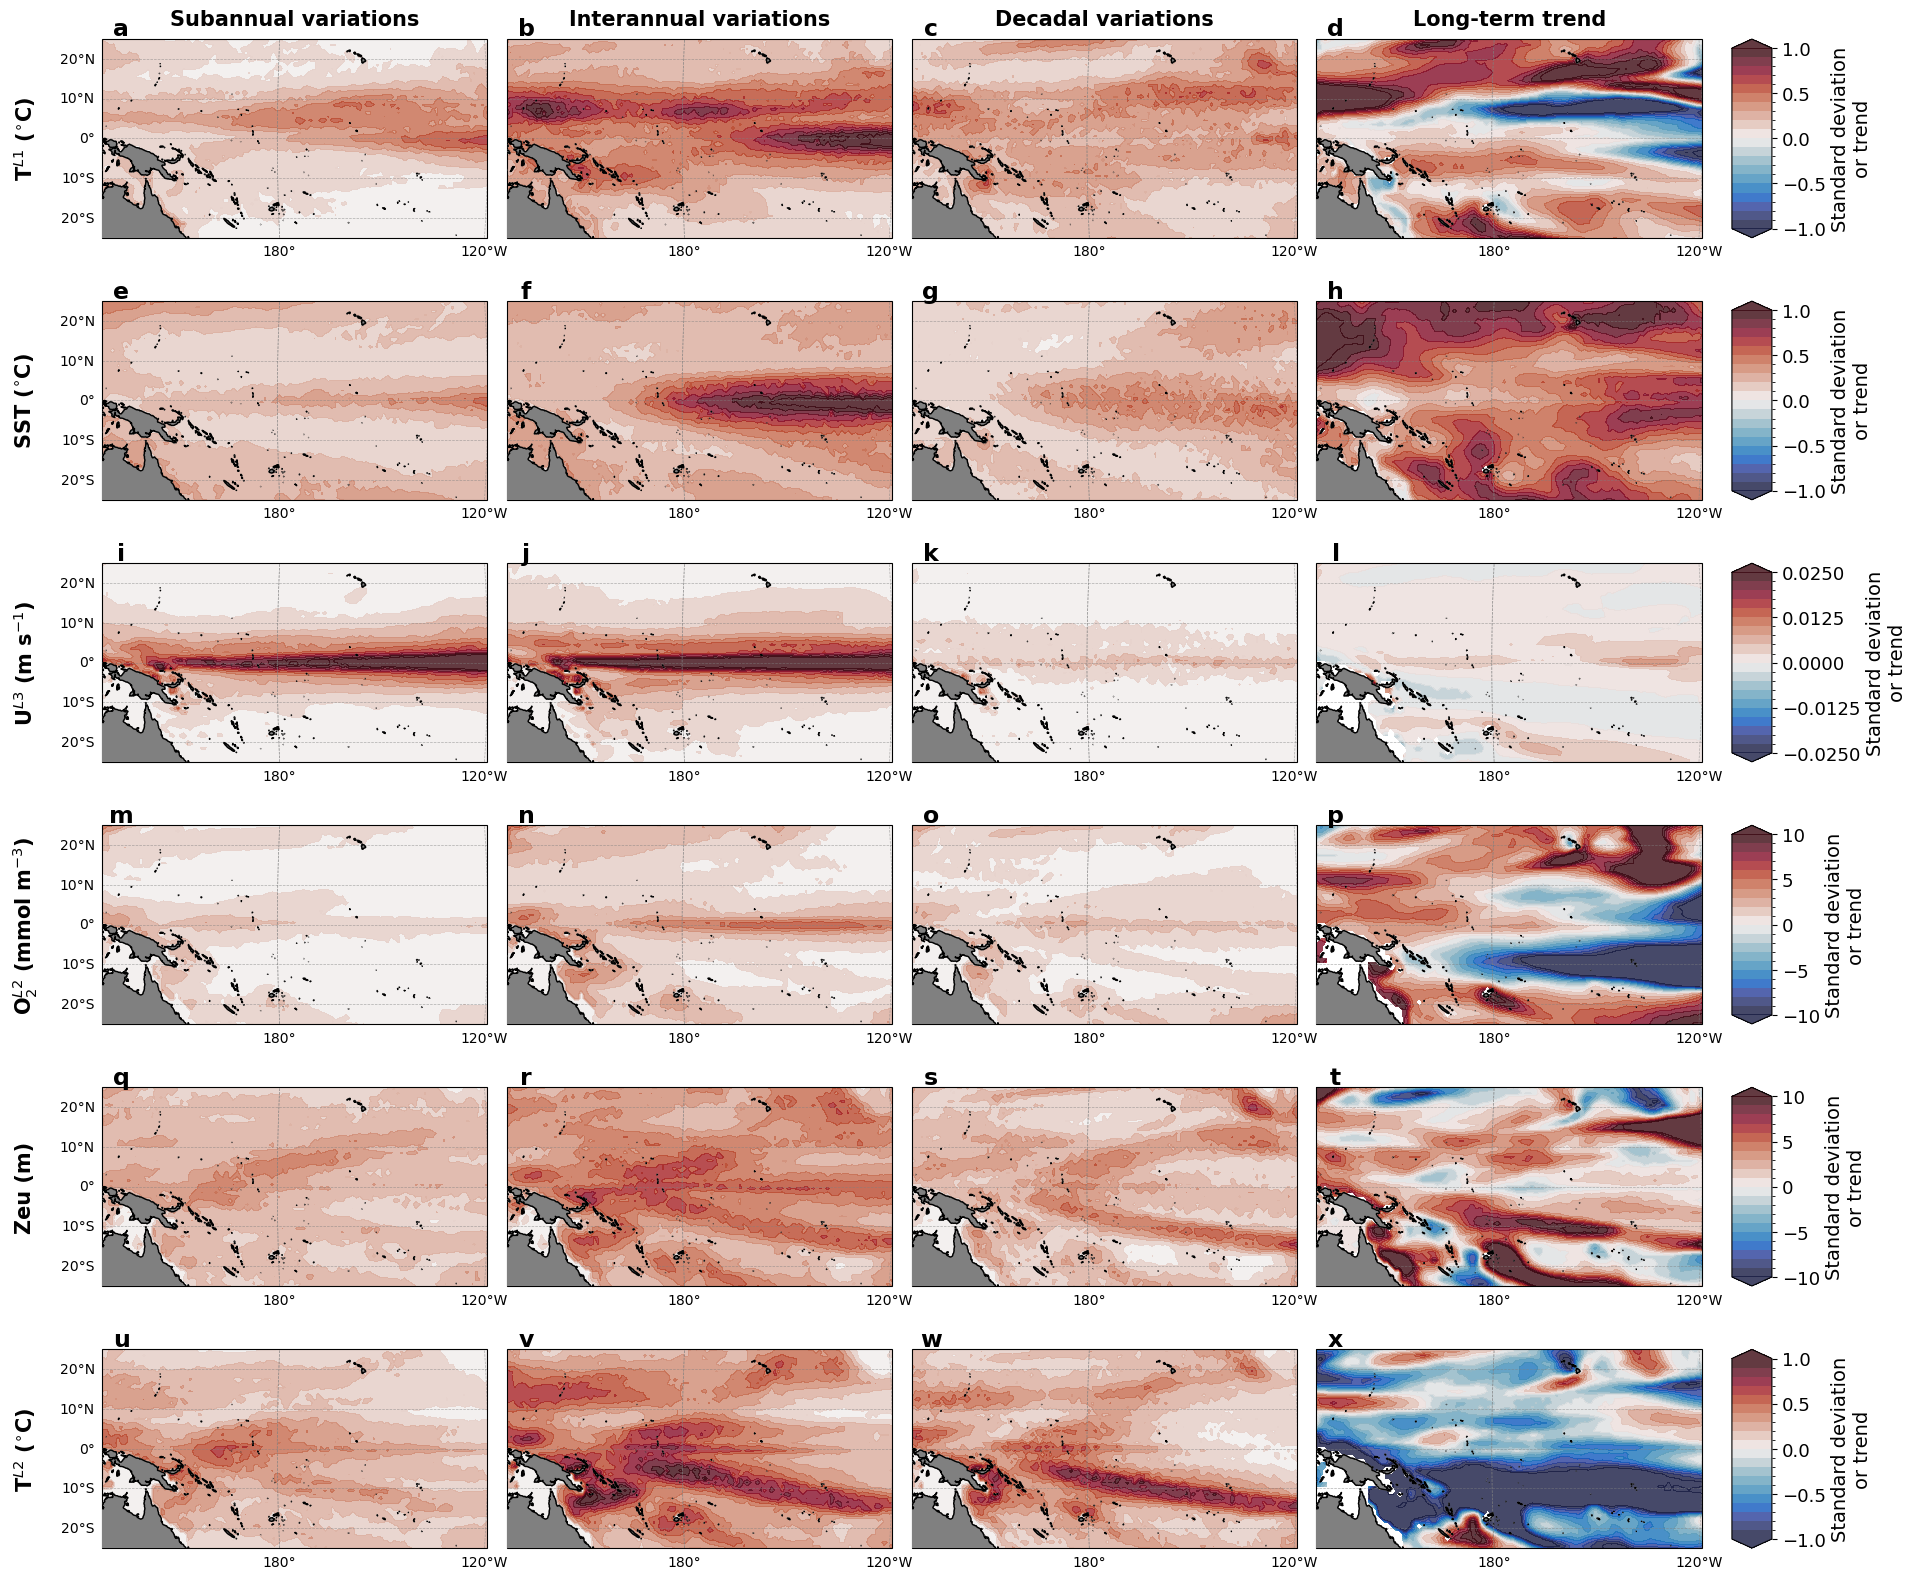

In [26]:
%%time

fslab = 15
fstic = 13

import matplotlib.lines as mlines
from cartopy.util import add_cyclic_point

proj = ccrs.Robinson(central_longitude=205)

colmap = lighten(cmo.amp, 0.8)
colmap2 = lighten(cmo.balance, 0.8)

levs1 = np.arange(0.0,1.01,0.1)
norm1 = mcolors.BoundaryNorm(levs1, ncolors=256)
levs2 = np.arange(0.0,1.01,0.1)
norm2 = mcolors.BoundaryNorm(levs2, ncolors=256)
levs3 = np.arange(0.0,0.0251,0.0025)
norm3 = mcolors.BoundaryNorm(levs3, ncolors=256)
levs4 = np.arange(0.0,10.1,1.0)
norm4 = mcolors.BoundaryNorm(levs4, ncolors=256)
levs5 = np.arange(0.0,10.1,1.0)
norm5 = mcolors.BoundaryNorm(levs5, ncolors=256)
levs6 = np.arange(0.0,1.01,0.1)
norm6 = mcolors.BoundaryNorm(levs6, ncolors=256)

levs1a = np.arange(-1.0,1.01,0.1)
norm1a = mcolors.BoundaryNorm(levs1a, ncolors=256)
levs2a = np.arange(-1.0,1.01,0.1)
norm2a = mcolors.BoundaryNorm(levs2a, ncolors=256)
levs3a = np.arange(-0.025,0.0251,0.0025)
norm3a = mcolors.BoundaryNorm(levs3a, ncolors=256)
levs4a = np.arange(-10.0,10.1,1.0)
norm4a = mcolors.BoundaryNorm(levs4a, ncolors=256)
levs5a = np.arange(-10.0,10.1,1.0)
norm5a = mcolors.BoundaryNorm(levs5a, ncolors=256)
levs6a = np.arange(-1.0,1.01,0.1)
norm6a = mcolors.BoundaryNorm(levs6a, ncolors=256)


fig = plt.figure(figsize=(20,20))
gs = GridSpec(6, 4)

ax1 = plt.subplot(gs[0,0], projection=proj)
ax2 = plt.subplot(gs[0,1], projection=proj)
ax3 = plt.subplot(gs[0,2], projection=proj)
ax4 = plt.subplot(gs[0,3], projection=proj)
ax5 = plt.subplot(gs[1,0], projection=proj)
ax6 = plt.subplot(gs[1,1], projection=proj)
ax7 = plt.subplot(gs[1,2], projection=proj)
ax8 = plt.subplot(gs[1,3], projection=proj)
ax9 = plt.subplot(gs[2,0], projection=proj)
ax10 = plt.subplot(gs[2,1], projection=proj)
ax11 = plt.subplot(gs[2,2], projection=proj)
ax12 = plt.subplot(gs[2,3], projection=proj)
ax13 = plt.subplot(gs[3,0], projection=proj)
ax14 = plt.subplot(gs[3,1], projection=proj)
ax15 = plt.subplot(gs[3,2], projection=proj)
ax16 = plt.subplot(gs[3,3], projection=proj)
ax17 = plt.subplot(gs[4,0], projection=proj)
ax18 = plt.subplot(gs[4,1], projection=proj)
ax19 = plt.subplot(gs[4,2], projection=proj)
ax20 = plt.subplot(gs[4,3], projection=proj)
ax21 = plt.subplot(gs[5,0], projection=proj)
ax22 = plt.subplot(gs[5,1], projection=proj)
ax23 = plt.subplot(gs[5,2], projection=proj)
ax24 = plt.subplot(gs[5,3], projection=proj)

p1 = ax1.contourf(lons, lats, T_L1_imfs.isel(IMF=0).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='max')
p2 = ax2.contourf(lons, lats, T_L1_imfs.isel(IMF=1).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='max')
p3 = ax3.contourf(lons, lats, T_L1_imfs.isel(IMF=2).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm1, levels=levs1, extend='max')
p4 = ax4.contourf(lons, lats, T_L1_imfs.isel(IMF=3).std(dim="time") + T_L1_trend_std, transform=ccrs.PlateCarree(), cmap=colmap2, norm=norm1a, levels=levs1a, extend='both')
p5 = ax5.contourf(lons, lats, sst_imfs.isel(IMF=0).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='max')
p6 = ax6.contourf(lons, lats, sst_imfs.isel(IMF=1).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='max')
p7 = ax7.contourf(lons, lats, sst_imfs.isel(IMF=2).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm2, levels=levs2, extend='max')
p8 = ax8.contourf(lons, lats, sst_imfs.isel(IMF=3).std(dim="time") + sst_trend_std, transform=ccrs.PlateCarree(), cmap=colmap2, norm=norm2a, levels=levs2a, extend='both')
p9 = ax9.contourf(lons, lats, U_L3_imfs.isel(IMF=0).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm3, levels=levs3, extend='max')
p10 = ax10.contourf(lons, lats, U_L3_imfs.isel(IMF=1).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm3, levels=levs3, extend='max')
p11 = ax11.contourf(lons, lats, U_L3_imfs.isel(IMF=2).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm3, levels=levs3, extend='max')
p12 = ax12.contourf(lons, lats, U_L3_imfs.isel(IMF=3).std(dim="time") + U_L3_trend_std, transform=ccrs.PlateCarree(), cmap=colmap2, norm=norm3a, levels=levs3a, extend='both')
p13 = ax13.contourf(lons, lats, O2_L3_imfs.isel(IMF=0).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm4, levels=levs4, extend='max')
p14 = ax14.contourf(lons, lats, O2_L3_imfs.isel(IMF=1).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm4, levels=levs4, extend='max')
p15 = ax15.contourf(lons, lats, O2_L3_imfs.isel(IMF=2).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm4, levels=levs4, extend='max')
p16 = ax16.contourf(lons, lats, O2_L3_imfs.isel(IMF=3).std(dim="time") + O2_L2_trend_std, transform=ccrs.PlateCarree(), cmap=colmap2, norm=norm4a, levels=levs4a, extend='both')
p17 = ax17.contourf(lons, lats, zeu_imfs.isel(IMF=0).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm5, levels=levs5, extend='max')
p18 = ax18.contourf(lons, lats, zeu_imfs.isel(IMF=1).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm5, levels=levs5, extend='max')
p19 = ax19.contourf(lons, lats, zeu_imfs.isel(IMF=2).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm5, levels=levs5, extend='max')
p20 = ax20.contourf(lons, lats, zeu_imfs.isel(IMF=3).std(dim="time") + zeu_trend_std, transform=ccrs.PlateCarree(), cmap=colmap2, norm=norm5a, levels=levs5a, extend='both')
p21 = ax21.contourf(lons, lats, T_L2_imfs.isel(IMF=0).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm6, levels=levs6, extend='max')
p22 = ax22.contourf(lons, lats, T_L2_imfs.isel(IMF=1).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm6, levels=levs6, extend='max')
p23 = ax23.contourf(lons, lats, T_L2_imfs.isel(IMF=2).std(dim="time"), transform=ccrs.PlateCarree(), cmap=colmap, norm=norm6, levels=levs6, extend='max')
p24 = ax24.contourf(lons, lats, T_L2_imfs.isel(IMF=3).std(dim="time") + T_L2_trend_std, transform=ccrs.PlateCarree(), cmap=colmap2, norm=norm6a, levels=levs6a, extend='both')


ax1.add_feature(cfeature.LAND, color='grey', zorder=3)
ax1.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax2.add_feature(cfeature.LAND, color='grey', zorder=3)
ax2.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax3.add_feature(cfeature.LAND, color='grey', zorder=3)
ax3.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax4.add_feature(cfeature.LAND, color='grey', zorder=3)
ax4.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax5.add_feature(cfeature.LAND, color='grey', zorder=3)
ax5.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax6.add_feature(cfeature.LAND, color='grey', zorder=3)
ax6.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax7.add_feature(cfeature.LAND, color='grey', zorder=3)
ax7.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax8.add_feature(cfeature.LAND, color='grey', zorder=3)
ax8.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax9.add_feature(cfeature.LAND, color='grey', zorder=3)
ax9.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax10.add_feature(cfeature.LAND, color='grey', zorder=3)
ax10.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax11.add_feature(cfeature.LAND, color='grey', zorder=3)
ax11.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax12.add_feature(cfeature.LAND, color='grey', zorder=3)
ax12.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax13.add_feature(cfeature.LAND, color='grey', zorder=3)
ax13.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax14.add_feature(cfeature.LAND, color='grey', zorder=3)
ax14.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax15.add_feature(cfeature.LAND, color='grey', zorder=3)
ax15.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax16.add_feature(cfeature.LAND, color='grey', zorder=3)
ax16.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax17.add_feature(cfeature.LAND, color='grey', zorder=3)
ax17.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax18.add_feature(cfeature.LAND, color='grey', zorder=3)
ax18.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax19.add_feature(cfeature.LAND, color='grey', zorder=3)
ax19.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax20.add_feature(cfeature.LAND, color='grey', zorder=3)
ax20.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax21.add_feature(cfeature.LAND, color='grey', zorder=3)
ax21.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax22.add_feature(cfeature.LAND, color='grey', zorder=3)
ax22.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax23.add_feature(cfeature.LAND, color='grey', zorder=3)
ax23.add_feature(cfeature.COASTLINE, color='k', zorder=4)
ax24.add_feature(cfeature.LAND, color='grey', zorder=3)
ax24.add_feature(cfeature.COASTLINE, color='k', zorder=4)


xx = 0.5; yy = 1.1
plt.text(xx,yy, 'Subannual variations', ha='center', va='center', fontweight='bold', transform=ax1.transAxes, fontsize=fslab)
plt.text(xx,yy, 'Interannual variations', ha='center', va='center', fontweight='bold', transform=ax2.transAxes, fontsize=fslab)
plt.text(xx,yy, 'Decadal variations', ha='center', va='center', fontweight='bold', transform=ax3.transAxes, fontsize=fslab)
plt.text(xx,yy, 'Long-term trend', ha='center', va='center', fontweight='bold', transform=ax4.transAxes, fontsize=fslab)

xx = -0.2; yy = 0.5
plt.text(xx,yy, 'T$^{L1}$ ($^{\circ}$C)', ha='center', va='center', fontweight='bold', transform=ax1.transAxes, rotation=90, fontsize=fslab)
plt.text(xx,yy, 'SST ($^{\circ}$C)', ha='center', va='center', fontweight='bold', transform=ax5.transAxes, rotation=90, fontsize=fslab)
plt.text(xx,yy, 'U$^{L3}$ (m s$^{-1}$)', ha='center', va='center', fontweight='bold', transform=ax9.transAxes, rotation=90, fontsize=fslab)
plt.text(xx,yy, 'O$_2^{L2}$ (mmol m$^{-3}$)', ha='center', va='center', fontweight='bold', transform=ax13.transAxes, rotation=90, fontsize=fslab)
plt.text(xx,yy, 'Zeu (m)', ha='center', va='center', fontweight='bold', transform=ax17.transAxes, rotation=90, fontsize=fslab)
plt.text(xx,yy, 'T$^{L2}$ ($^{\circ}$C)', ha='center', va='center', fontweight='bold', transform=ax21.transAxes, rotation=90, fontsize=fslab)

xx = 0.05
yy = 1.05
plt.text(xx,yy, 'a', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax1.transAxes)
plt.text(xx,yy, 'b', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax2.transAxes)
plt.text(xx,yy, 'c', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax3.transAxes)
plt.text(xx,yy, 'd', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax4.transAxes)
plt.text(xx,yy, 'e', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax5.transAxes)
plt.text(xx,yy, 'f', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax6.transAxes)
plt.text(xx,yy, 'g', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax7.transAxes)
plt.text(xx,yy, 'h', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax8.transAxes)
plt.text(xx,yy, 'i', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax9.transAxes)
plt.text(xx,yy, 'j', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax10.transAxes)
plt.text(xx,yy, 'k', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax11.transAxes)
plt.text(xx,yy, 'l', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax12.transAxes)
plt.text(xx,yy, 'm', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax13.transAxes)
plt.text(xx,yy, 'n', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax14.transAxes)
plt.text(xx,yy, 'o', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax15.transAxes)
plt.text(xx,yy, 'p', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax16.transAxes)
plt.text(xx,yy, 'q', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax17.transAxes)
plt.text(xx,yy, 'r', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax18.transAxes)
plt.text(xx,yy, 's', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax19.transAxes)
plt.text(xx,yy, 't', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax20.transAxes)
plt.text(xx,yy, 'u', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax21.transAxes)
plt.text(xx,yy, 'v', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax22.transAxes)
plt.text(xx,yy, 'w', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax23.transAxes)
plt.text(xx,yy, 'x', fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax24.transAxes)

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

gl1 = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl2 = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl3 = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl4 = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl5 = ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl6 = ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl7 = ax7.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl8 = ax8.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl9 = ax9.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl10 = ax10.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl11 = ax11.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl12 = ax12.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl13 = ax13.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl14 = ax14.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl15 = ax15.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl16 = ax16.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl17 = ax17.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl18 = ax18.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl19 = ax19.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl20 = ax20.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl21 = ax21.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl22 = ax22.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl23 = ax23.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')
gl24 = ax24.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.6, linestyle='--')

gl1.top_labels = False; gl1.right_labels = False
gl2.top_labels = False; gl2.right_labels = False; gl2.left_labels = False
gl3.top_labels = False; gl3.right_labels = False; gl3.left_labels = False
gl4.top_labels = False; gl4.right_labels = False; gl4.left_labels = False
gl5.top_labels = False; gl5.right_labels = False
gl6.top_labels = False; gl6.right_labels = False; gl6.left_labels = False
gl7.top_labels = False; gl7.right_labels = False; gl7.left_labels = False
gl8.top_labels = False; gl8.right_labels = False; gl8.left_labels = False
gl9.top_labels = False; gl9.right_labels = False
gl10.top_labels = False; gl10.right_labels = False; gl10.left_labels = False
gl11.top_labels = False; gl11.right_labels = False; gl11.left_labels = False
gl12.top_labels = False; gl12.right_labels = False; gl12.left_labels = False
gl13.top_labels = False; gl13.right_labels = False
gl14.top_labels = False; gl14.right_labels = False; gl14.left_labels = False
gl15.top_labels = False; gl15.right_labels = False; gl15.left_labels = False
gl16.top_labels = False; gl16.right_labels = False; gl16.left_labels = False
gl17.top_labels = False; gl17.right_labels = False
gl18.top_labels = False; gl18.right_labels = False; gl18.left_labels = False
gl19.top_labels = False; gl19.right_labels = False; gl19.left_labels = False
gl20.top_labels = False; gl20.right_labels = False; gl20.left_labels = False
gl21.top_labels = False; gl21.right_labels = False
gl22.top_labels = False; gl22.right_labels = False; gl22.left_labels = False
gl23.top_labels = False; gl23.right_labels = False; gl23.left_labels = False
gl24.top_labels = False; gl24.right_labels = False; gl24.left_labels = False

ax1.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax2.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax3.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax4.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax5.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax6.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax7.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax8.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax9.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax10.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax11.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax12.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax13.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax14.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax15.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax16.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax17.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax18.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax19.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax20.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax21.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax22.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax23.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())
ax24.set_extent([130, 240, -25, 25], crs=ccrs.PlateCarree())

plt.subplots_adjust(wspace=0.05, hspace=0.05, left=0.075, right=0.875, bottom=0.1)

pos1 = ax4.get_position()
pos2 = ax8.get_position()
pos3 = ax12.get_position()
pos4 = ax16.get_position()
pos5 = ax20.get_position()
pos6 = ax24.get_position()
cbax1 = fig.add_axes([pos1.x1+0.015,pos1.y0,0.02,pos1.y1-pos1.y0])
cbax2 = fig.add_axes([pos2.x1+0.015,pos2.y0,0.02,pos2.y1-pos2.y0])
cbax3 = fig.add_axes([pos3.x1+0.015,pos3.y0,0.02,pos3.y1-pos3.y0])
cbax4 = fig.add_axes([pos4.x1+0.015,pos4.y0,0.02,pos4.y1-pos4.y0])
cbax5 = fig.add_axes([pos5.x1+0.015,pos5.y0,0.02,pos5.y1-pos5.y0])
cbax6 = fig.add_axes([pos6.x1+0.015,pos6.y0,0.02,pos6.y1-pos6.y0])

cbar1 = plt.colorbar(p4, cax=cbax1, orientation='vertical', ticks=levs1a[::5])
cbar1.ax.tick_params(labelsize=fstic)
cbar1.ax.set_ylabel("Standard deviation\nor trend", fontsize=fslab-1)

cbar2 = plt.colorbar(p8, cax=cbax2, orientation='vertical', ticks=levs2a[::5])
cbar2.ax.tick_params(labelsize=fstic)
cbar2.ax.set_ylabel("Standard deviation\nor trend", fontsize=fslab-1)

cbar3 = plt.colorbar(p12, cax=cbax3, orientation='vertical', ticks=levs3a[::5])
cbar3.ax.tick_params(labelsize=fstic)
cbar3.ax.set_ylabel("Standard deviation\nor trend", fontsize=fslab-1)

cbar4 = plt.colorbar(p16, cax=cbax4, orientation='vertical', ticks=levs4a[::5])
cbar4.ax.tick_params(labelsize=fstic)
cbar4.ax.set_ylabel("Standard deviation\nor trend", fontsize=fslab-1)

cbar5 = plt.colorbar(p20, cax=cbax5, orientation='vertical', ticks=levs5a[::5])
cbar5.ax.tick_params(labelsize=fstic)
cbar5.ax.set_ylabel("Standard deviation\nor trend", fontsize=fslab-1)

cbar6 = plt.colorbar(p24, cax=cbax6, orientation='vertical', ticks=levs6a[::5])
cbar6.ax.tick_params(labelsize=fstic)
cbar6.ax.set_ylabel("Standard deviation\nor trend", fontsize=fslab-1)


In [27]:
fig.savefig("/g/data/es60/SEAPODYM/pearse_GAMs/figures/STD_of_key_predictors.png", dpi=300, bbox_inches='tight')

In [28]:
os.getcwd()

'/g/data/es60/SEAPODYM/pearse_GAMs'